# CREDIT RISK MODELING & LOAN DEFAULT ANALYSIS



### BUSINESS SCENARIO AND PROBLEM

Home Credit is a consumer finance provider operating across nine countries, serving borrowers who are largely underserved by traditional banking — individuals with limited or no formal credit history. With over 300,000 loan applications on record, the company faces a challenge every lender in this segment confronts: the applicants most in need of credit are also the hardest to assess for risk.

Current loan approvals rely on traditional credit bureau scores and manual underwriting — a process that is inconsistent, slow to scale, and poorly calibrated for nontraditional borrowers. The result is a dual failure: high-risk applicants slip through and default, generating direct financial losses; and creditworthy applicants are rejected because their profiles don't fit conventional scoring models, destroying potential revenue at the same time.

The credit team needs to understand which applicant characteristics actually predict default, where the current assessment process is mispricing risk, and how to make lending decisions that are faster, more consistent, and defensible to senior leadership.

### QUESTIONS FROM STAKEHOLDERS

1. Which applicant characteristics are the strongest predictors of loan default?
2. How accurately can historical application data predict which applicants will default?
3. At what probability threshold should an applicant be classified as high-risk — and what is the financial trade-off of that decision?
4. How should applicants be segmented into approval tiers, and what is the expected default rate within each tier?
5. Which applicants are being incorrectly assessed — and where is risk being mispriced?

# PLAN STAGE

In [2]:
# import the necessary libraries and modules

# data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier , plot_importance 

# model selection and preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler , LabelEncoder

# metrics for evaluation and validation
from sklearn.metrics import average_precision_score, recall_score, precision_score, accuracy_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# imbalance and interpretability
from imblearn.over_sampling import SMOTE
import shap

# utilities
import warnings
warnings.filterwarnings("ignore")

C:\Users\Samarth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET LOADING AND EXPLORATION

In [3]:
# load the dataset

data = pd.read_csv('application_train.csv')

In [4]:
# check the dataset

data.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# check the shape

data.shape

(307511, 122)

In [6]:
# check for datatypes

data.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE                str
CODE_GENDER                       str
FLAG_OWN_CAR                      str
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [7]:
# gather basic info about the dataset

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [8]:
# gather basic statistics about the dataset

data.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
# check the target column distribution

data['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

DATA CLEANING AND TRANSFORMATION

In [10]:
# display missing value count and percentage for all columns

missing = pd.DataFrame({'missing_count': data.isnull().sum(),'missing_pct': (data.isnull().sum() / len(data) * 100).round(2)}).sort_values('missing_pct', ascending=True)

pd.set_option('display.max_rows', 122)
print(missing)

                              missing_count  missing_pct
SK_ID_CURR                                0         0.00
TARGET                                    0         0.00
NAME_CONTRACT_TYPE                        0         0.00
CODE_GENDER                               0         0.00
FLAG_OWN_CAR                              0         0.00
FLAG_OWN_REALTY                           0         0.00
CNT_CHILDREN                              0         0.00
AMT_INCOME_TOTAL                          0         0.00
AMT_CREDIT                                0         0.00
AMT_ANNUITY                              12         0.00
NAME_EDUCATION_TYPE                       0         0.00
NAME_INCOME_TYPE                          0         0.00
NAME_FAMILY_STATUS                        0         0.00
NAME_HOUSING_TYPE                         0         0.00
DAYS_BIRTH                                0         0.00
REGION_POPULATION_RELATIVE                0         0.00
CNT_FAM_MEMBERS                

In [11]:
# drop identifier column

data.drop(columns=['SK_ID_CURR'], inplace=True)

In [12]:
# drop flag document columns — binary document submission flags, no default signal

flag_doc_cols = [col for col in data.columns if col.upper().startswith('FLAG_DOCUMENT')]
data.drop(columns=flag_doc_cols, inplace=True)

In [13]:
# drop building and property measurement columns — 48-70% missing, not predictive of individual credit risk

building_suffixes = ('_AVG', '_MEDI', '_MODE')
building_cols = [
    col for col in data.columns
    if col.upper().endswith(building_suffixes)
    and col.upper() not in ('EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3')
]
data.drop(columns=building_cols, inplace=True)

In [14]:
# rename all columns to snake_case

data.columns = data.columns.str.lower()

In [15]:
# confirm final shape

print(f"columns remaining after drops: {data.shape[1]}")
print(f"rows: {data.shape[0]}")

columns remaining after drops: 54
rows: 307511


ANOMALY HANDLING

In [16]:
# replace days_employed anomaly with NaN

data['days_employed'] = data['days_employed'].replace(365243, np.nan)

In [17]:
# convert negative days columns to positive years

data['days_birth'] = abs(data['days_birth']) / 365
data['days_employed'] = abs(data['days_employed']) / 365
data['days_registration'] = abs(data['days_registration']) / 365
data['days_id_publish'] = abs(data['days_id_publish']) / 365
data['days_last_phone_change'] = abs(data['days_last_phone_change']) / 365

In [18]:
# rename converted columns to reflect actual meaning

data.rename(columns={
    'days_birth': 'age_years',
    'days_employed': 'employment_years',
    'days_registration': 'registration_years',
    'days_id_publish': 'id_publish_years'
}, inplace=True)
data.head(10)

,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,2.0,2.0,2.0,3.106849,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,1.0,0.0,2.268493,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,2.232877,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0.0,2.0,0.0,1.690411,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,3.030137,0.0,0.0,0.0,0.0,0.0,0.0
5,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,454500.0,...,0.0,0.0,0.0,6.947945,0.0,0.0,0.0,0.0,1.0,1.0
6,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,1395000.0,...,0.0,1.0,0.0,4.279452,0.0,0.0,0.0,1.0,1.0,2.0
7,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,1530000.0,...,0.0,2.0,0.0,2.931507,0.0,0.0,0.0,0.0,0.0,0.0
8,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,913500.0,...,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0
9,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,405000.0,...,0.0,2.0,0.0,4.583562,NaN,NaN,NaN,NaN,NaN,NaN


HANDLING MISSING VALUES

In [19]:
# impute missing values in numerical columns with median

num_cols = data.select_dtypes(include=['number']).columns.difference(['target'])
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

In [20]:
# impute missing values in categorical columns with mode

cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns

for col in cat_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

In [21]:
# confirm no nulls
print(data.isnull().sum().sum())

# final shape
print(data.shape)

0
(307511, 54)


# PLAN STAGE SUMMARY

- Loaded the Home Credit Default Risk dataset containing 307,511 loan applications 
  across 122 columns — covering applicant demographics, financials, employment history, 
  and external credit scores.
- Reviewed dataset structure, data types, and summary statistics to understand variable distributions, scale, and data quality
- Target variable confirmed as heavily imbalanced — 282,686 repaid (91.94%) vs 24,825 
  defaulted (8.06%) — establishing ROC-AUC and F1-score as the primary evaluation 
  metrics over accuracy
- Missing value audit identified EXT_SOURCE_1 (56.38%), OWN_CAR_AGE (65.99%), and 
  building measurement columns (48–70%) as the most critically null features
- Removed SK_ID_CURR, 19 FLAG_DOCUMENT columns, and ~45 building and property 
  measurement columns — reducing the dataset from 122 to 54 columns
- Standardized column names to snake_case to maintain consistency and improve readability across the dataset  
- Replaced 365,243 sentinel values in days_employed with NaN — a placeholder 
  representing unemployed and pensioner applicants — prior to any conversion
- Converted days_birth, days_employed, days_registration, days_id_publish, and 
  days_last_phone_change from negative day values to positive year-based metrics and 
  renamed accordingly for interpretability
- Imputed remaining nulls using median for numerical columns and mode for categorical 
  columns — zero nulls confirmed post-imputation
- Final cleaned dataset: 307,511 rows × 54 columns — ready for exploratory data analysis

# ANALYSE STAGE

### EXPLORATORY DATA ANALYSIS

In [22]:
# set global plot style for the analyse stage

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

NUMERICAL EDA

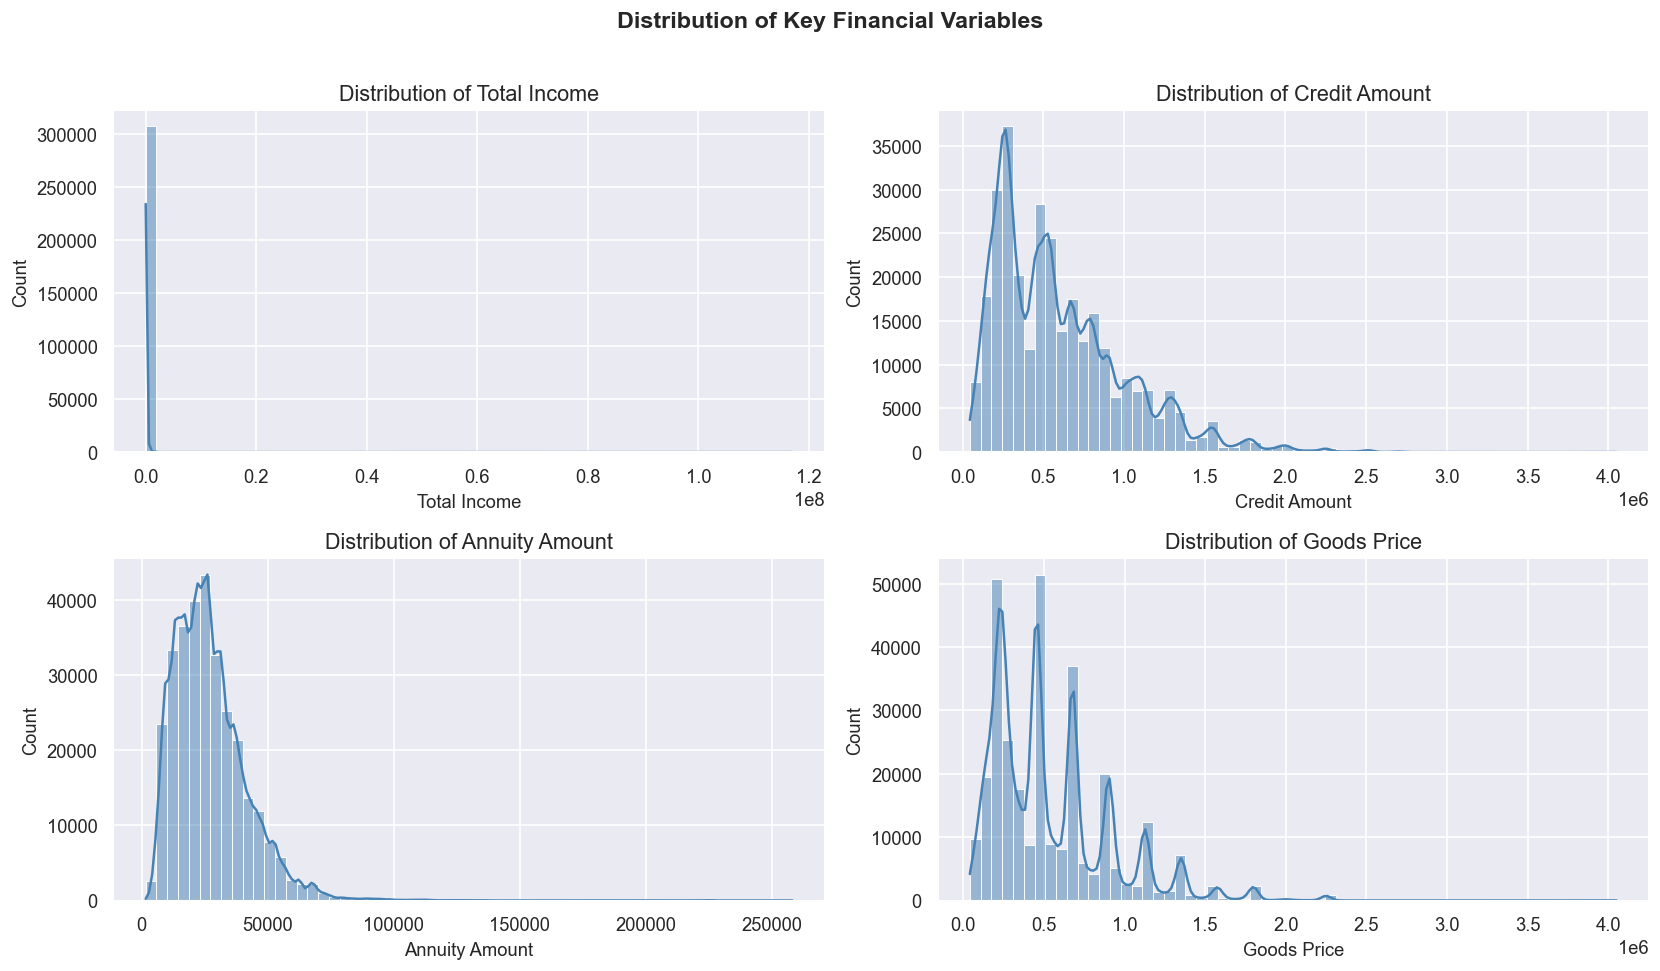

In [23]:
# distribution plots for key loan amount and income columns

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ['amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price']
titles = ['Total Income', 'Credit Amount', 'Annuity Amount', 'Goods Price']

for ax, col, title in zip(axes.flatten(), cols, titles):
    sns.histplot(data[col], bins=60, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Key Financial Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Income is severely right-skewed with most applicants earning below ₹200K, while credit amount and goods price show distinct multi-modal spikes likely reflecting standardized loan product tiers.
- All four variables carry extreme outliers that will compress the box plots and distort model training — Winsorization is required before the Construct stage.

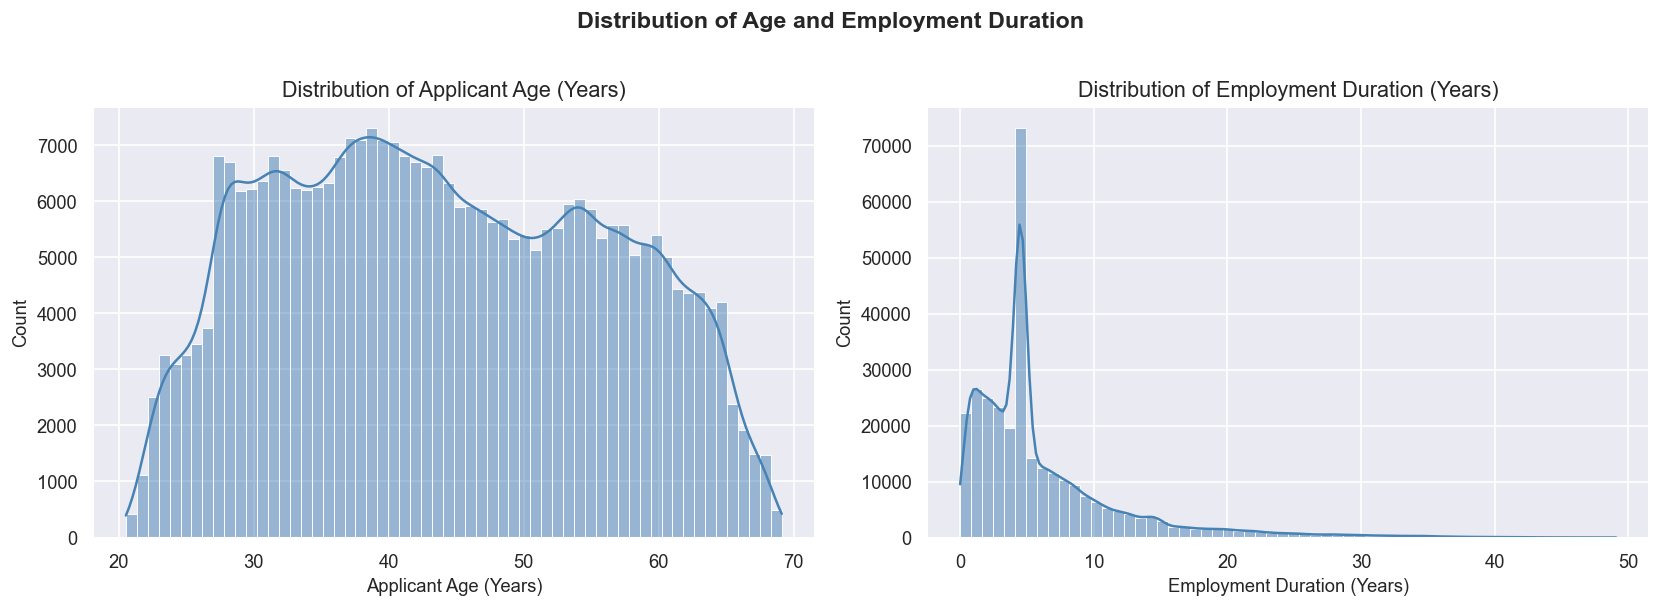

In [24]:
# distribution plots for age and employment years

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ['age_years', 'employment_years']
titles = ['Applicant Age (Years)', 'Employment Duration (Years)']

for ax, col, title in zip(axes, cols, titles):
    sns.histplot(data[col], bins=60, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Age and Employment Duration', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Applicant age peaks around 35–40 years with a secondary concentration at 50–60, indicating the portfolio spans both early-career and pre-retirement borrowers.
- Employment duration is sharply right-skewed with most applicants clustered under 5 years in their current job — the spike near zero flags a meaningful share of very recently employed applicants who carry elevated risk.

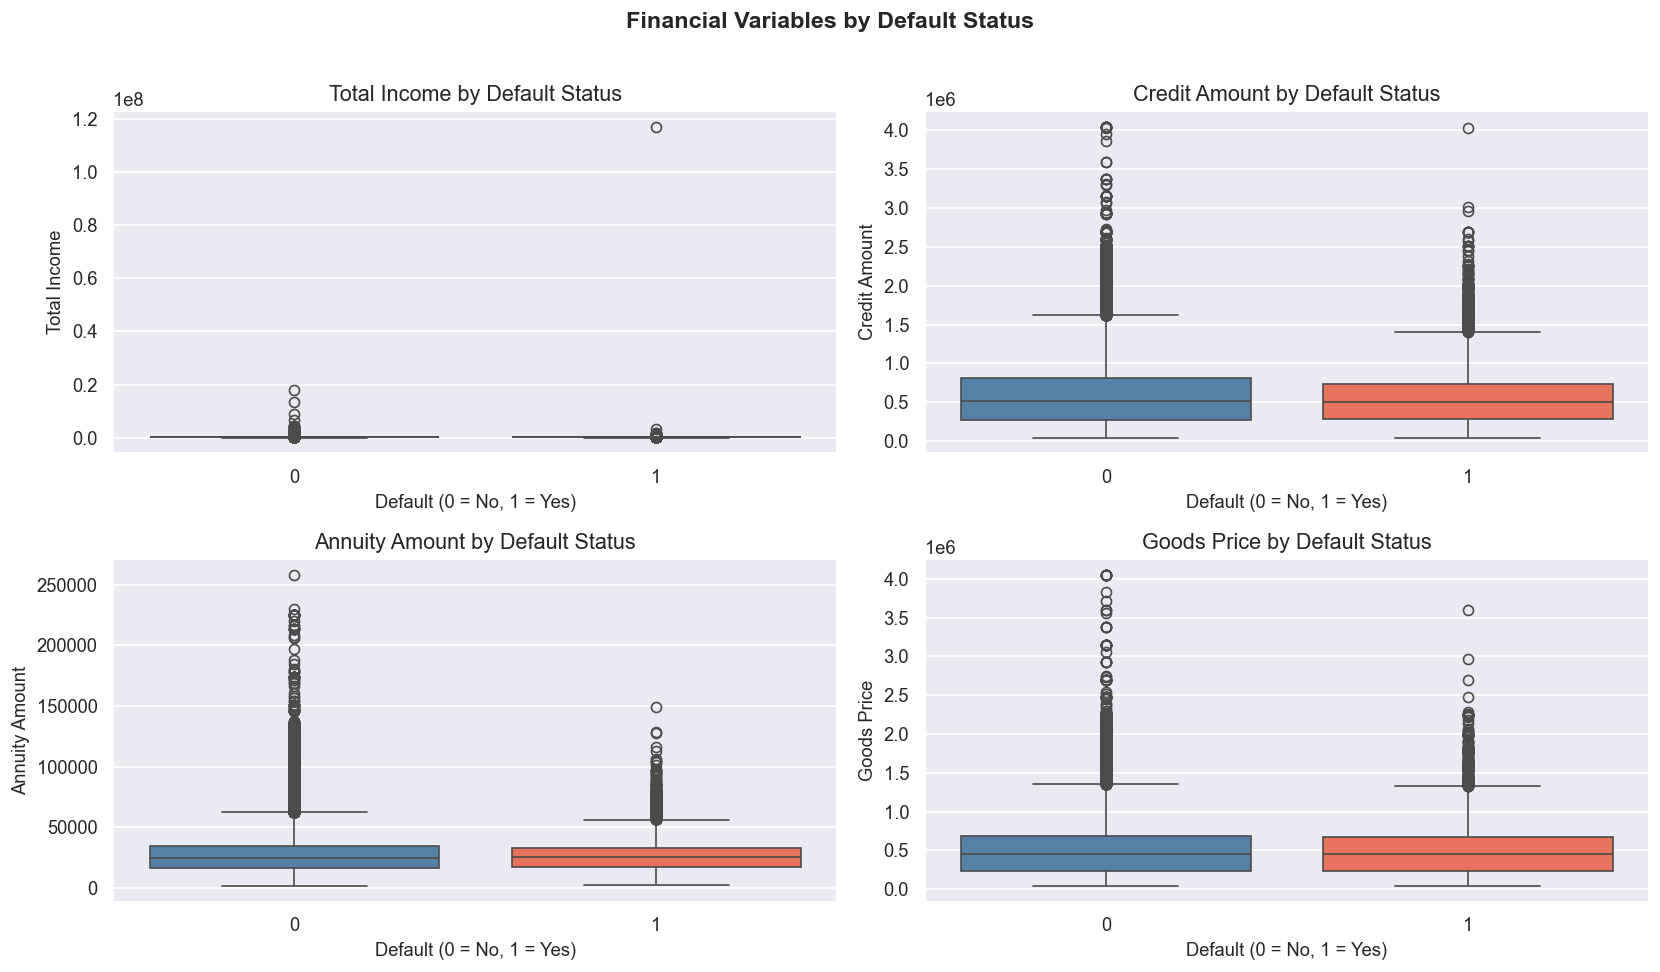

In [25]:
# box plots of financial variables split by default status

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ['amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price']
titles = ['Total Income', 'Credit Amount', 'Annuity Amount', 'Goods Price']

for ax, col, title in zip(axes.flatten(), cols, titles):
    sns.boxplot(x='target', y=col, data=data, ax=ax,
                palette=['steelblue', 'tomato'])
    ax.set_title(f'{title} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel(title)

plt.suptitle('Financial Variables by Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Median income, credit, annuity, and goods price are nearly identical between defaulters and non-defaulters — raw loan amounts alone are weak separators for default risk.
- The real signal lies in ratios: credit-to-income and annuity-to-income will be engineered in the Construct stage to surface what individual amounts cannot.

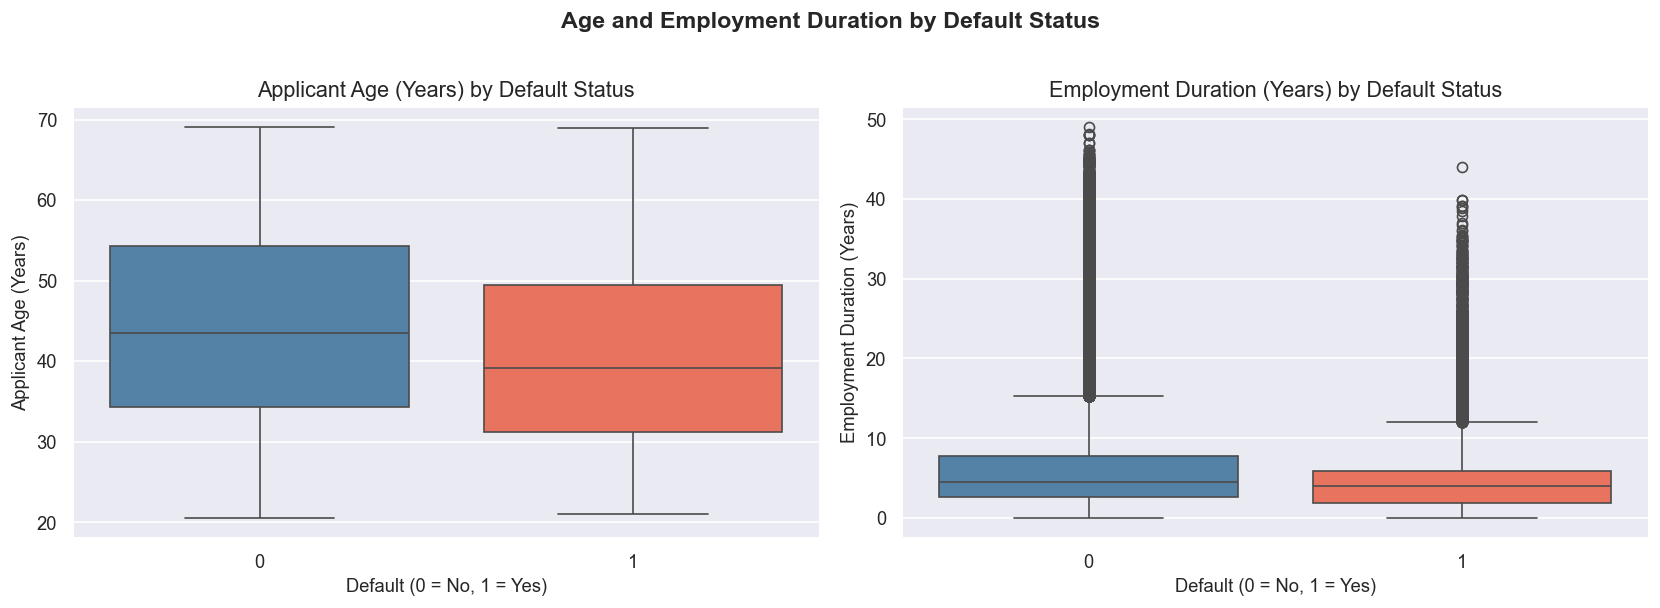

In [26]:
# box plots of age and employment years split by default status

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ['age_years', 'employment_years']
titles = ['Applicant Age (Years)', 'Employment Duration (Years)']

for ax, col, title in zip(axes, cols, titles):
    sns.boxplot(x='target', y=col, data=data, ax=ax, palette=['steelblue', 'tomato'])
    ax.set_title(f'{title} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel(title)

plt.suptitle('Age and Employment Duration by Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Defaulters are visibly younger — their median age sits around 38 years versus approximately 44 for non-defaulters, making age one of the stronger demographic separators in the dataset.
- Employment duration shows almost no separation between the two groups and will contribute meaningful signal only when combined with income and loan size as engineered features.

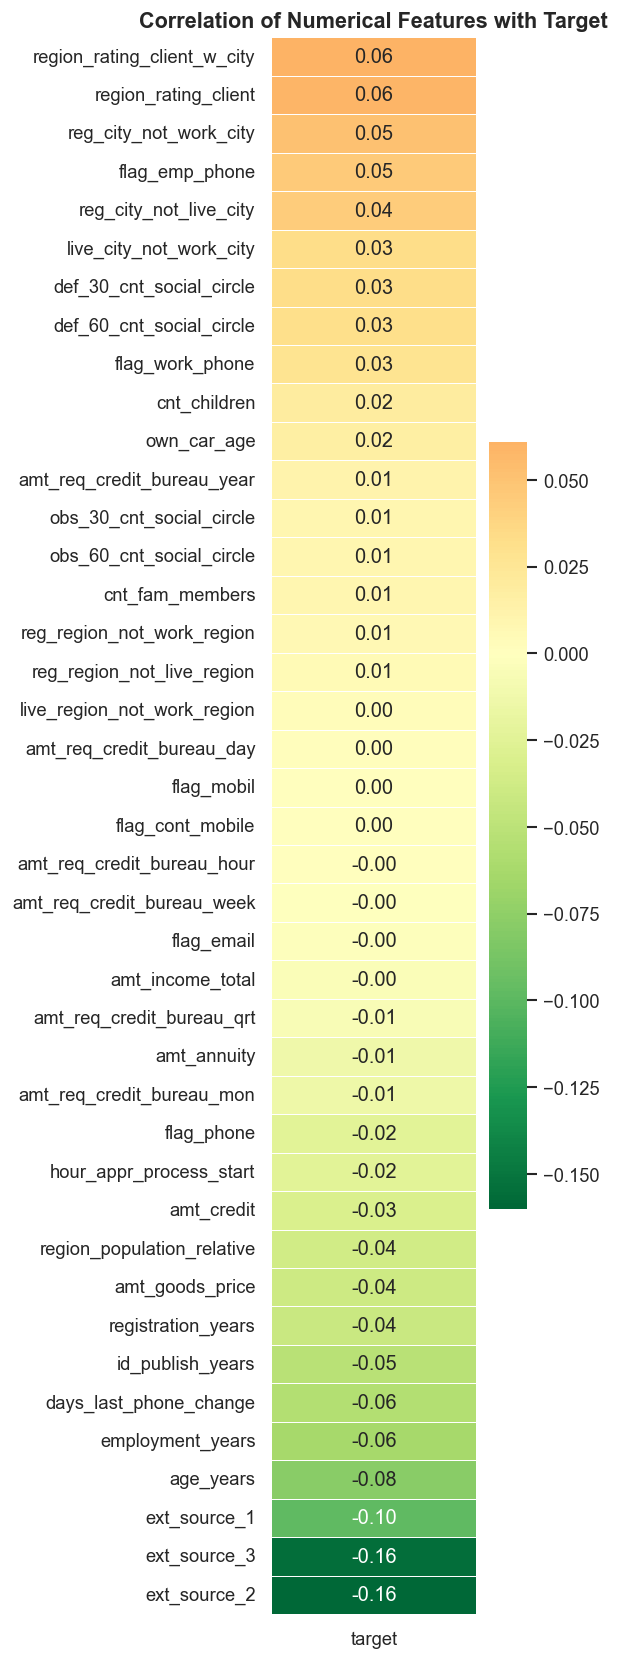

In [27]:
# correlation heatmap of numerical features with target

num_cols = data.select_dtypes(include='number').columns.tolist()
corr_with_target = data[num_cols].corr()[['target']].drop('target').sort_values('target', ascending=False)

plt.figure(figsize=(5, 14))
sns.heatmap(corr_with_target, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.6})
plt.title('Correlation of Numerical Features with Target', fontweight='bold')
plt.tight_layout()
plt.show()

**OBSERVATION**
- ext_source_2 and ext_source_3 are the strongest numerical predictors at -0.16 each, followed by ext_source_1 at -0.10 — all three confirm that higher external credit scores directly correspond to lower default probability.
- All raw financial variables (income, credit, annuity) correlate near zero with target individually, confirming their predictive value is locked in ratios rather than absolute amounts.

CATEGORICAL EDA

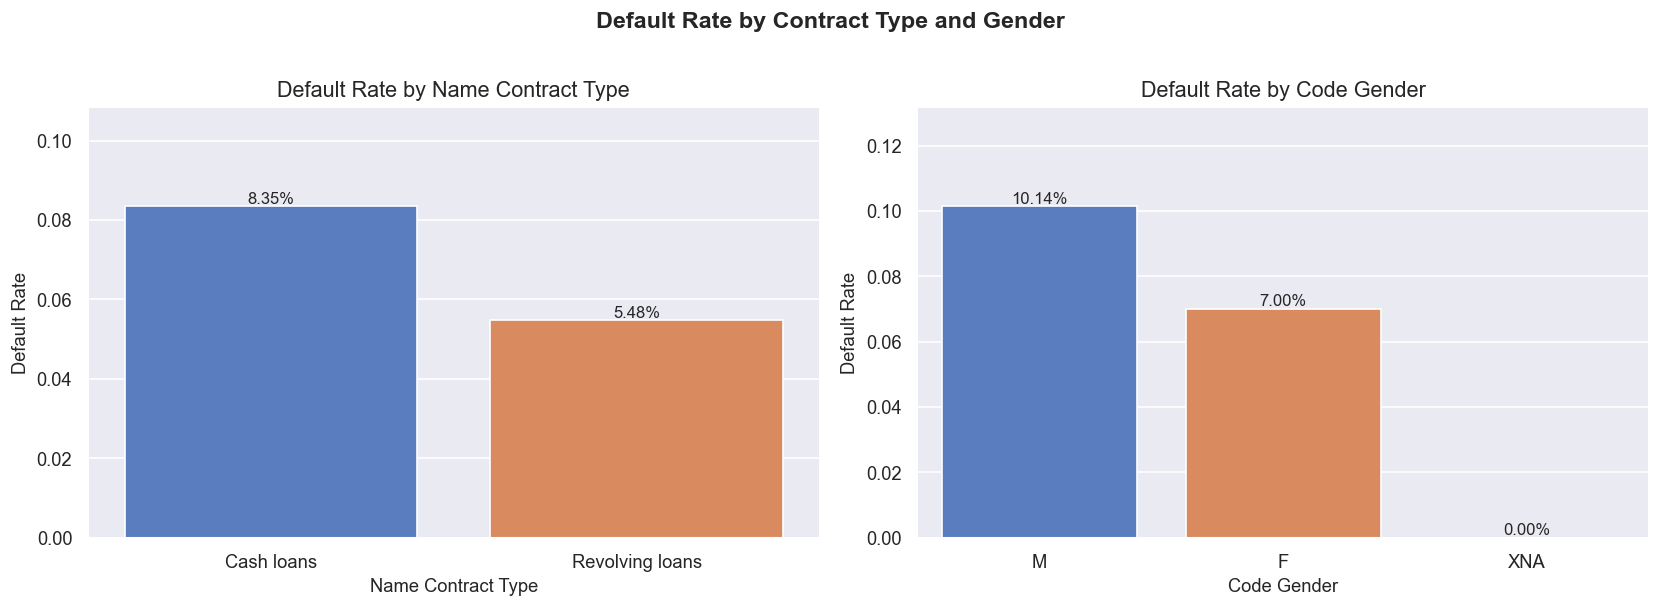

In [28]:
# default rate by contract type and gender

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_cols = ['name_contract_type', 'code_gender']

for ax, col in zip(axes, cat_cols):
    default_rate = data.groupby(col)['target'].mean().sort_values(ascending=False).reset_index()
    default_rate.columns = [col, 'default_rate']
    sns.barplot(x=col, y='default_rate', data=default_rate, ax=ax, palette='muted')
    ax.set_title(f'Default Rate by {col.replace("_", " ").title()}')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Default Rate')
    ax.set_ylim(0, default_rate['default_rate'].max() * 1.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Default Rate by Contract Type and Gender', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Cash loans default at 8.35% versus 5.48% for revolving loans — borrowers taking larger lump-sum products carry meaningfully higher risk than those using flexible credit lines.
- Male applicants default at 10.14% compared to 7.00% for females, making gender one of the cleaner categorical separators in the dataset.

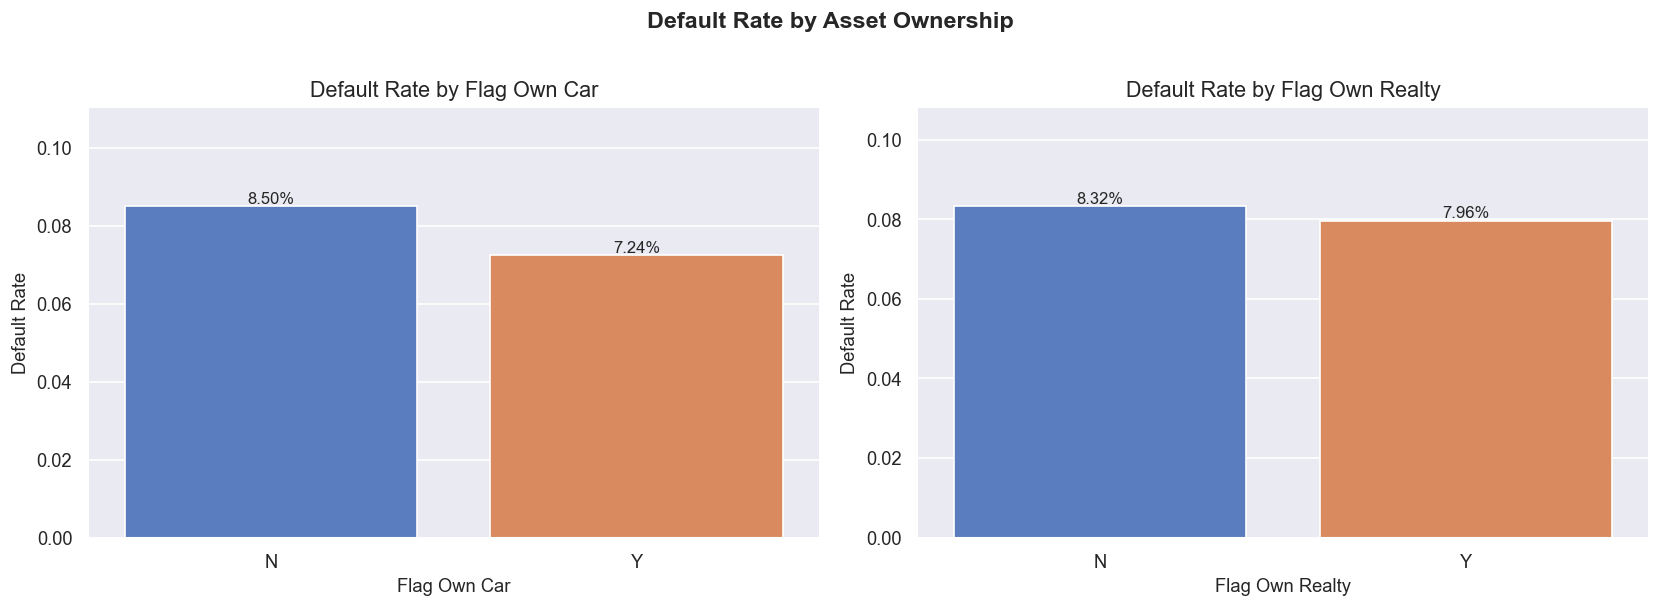

In [29]:
# default rate by car ownership and realty ownership

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_cols = ['flag_own_car', 'flag_own_realty']

for ax, col in zip(axes, cat_cols):
    default_rate = data.groupby(col)['target'].mean().sort_values(ascending=False).reset_index()
    default_rate.columns = [col, 'default_rate']
    sns.barplot(x=col, y='default_rate', data=default_rate, ax=ax, palette='muted')
    ax.set_title(f'Default Rate by {col.replace("_", " ").title()}')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Default Rate')
    ax.set_ylim(0, default_rate['default_rate'].max() * 1.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Default Rate by Asset Ownership', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Both car and realty ownership show only marginal default rate differences (8.50% vs 7.24% for car; 8.32% vs 7.96% for realty) — asset ownership is a weak standalone signal and will contribute limited predictive lift individually.

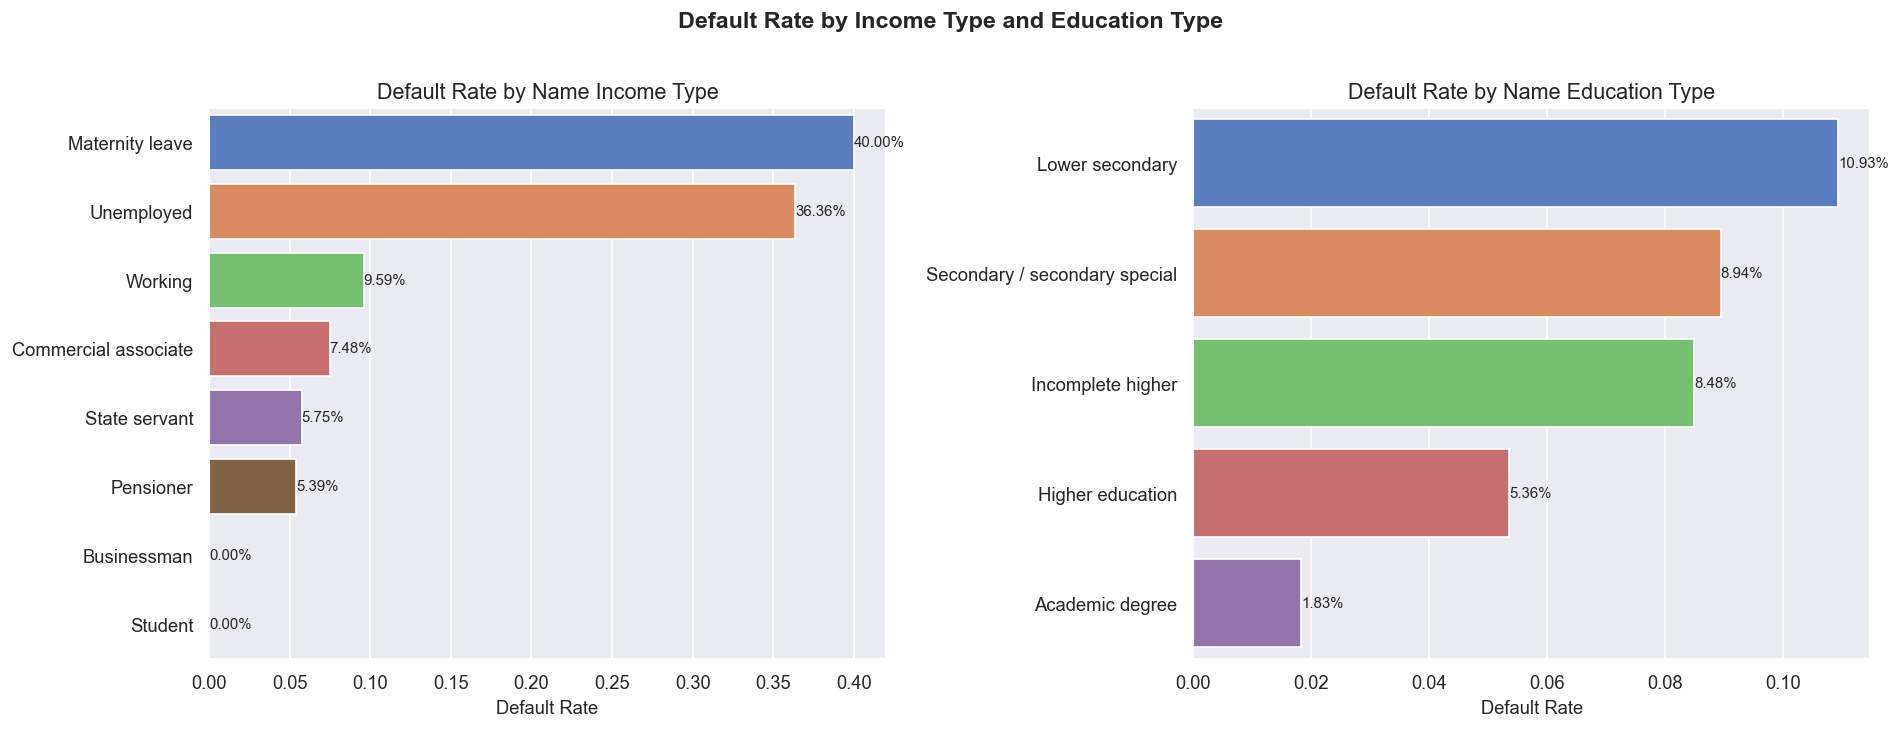

In [30]:
# default rate by income type and education type

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cat_cols = ['name_income_type', 'name_education_type']

for ax, col in zip(axes, cat_cols):
    default_rate = data.groupby(col)['target'].mean().sort_values(ascending=False).reset_index()
    default_rate.columns = [col, 'default_rate']
    sns.barplot(x='default_rate', y=col, data=default_rate, ax=ax, palette='muted', orient='h')
    ax.set_title(f'Default Rate by {col.replace("_", " ").title()}')
    ax.set_xlabel('Default Rate')
    ax.set_ylabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2%}', (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9)

plt.suptitle('Default Rate by Income Type and Education Type', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Maternity leave (40%) and unemployed (36.36%) applicants default at rates far above the dataset average of 8.06% — these segments represent extreme concentration risk and their small sample sizes make the rates volatile but directionally significant.
- Education level shows a clean inverse relationship with default risk: lower secondary graduates default at 10.93% while academic degree holders sit at just 1.83%, confirming that education is a strong proxy for financial stability.

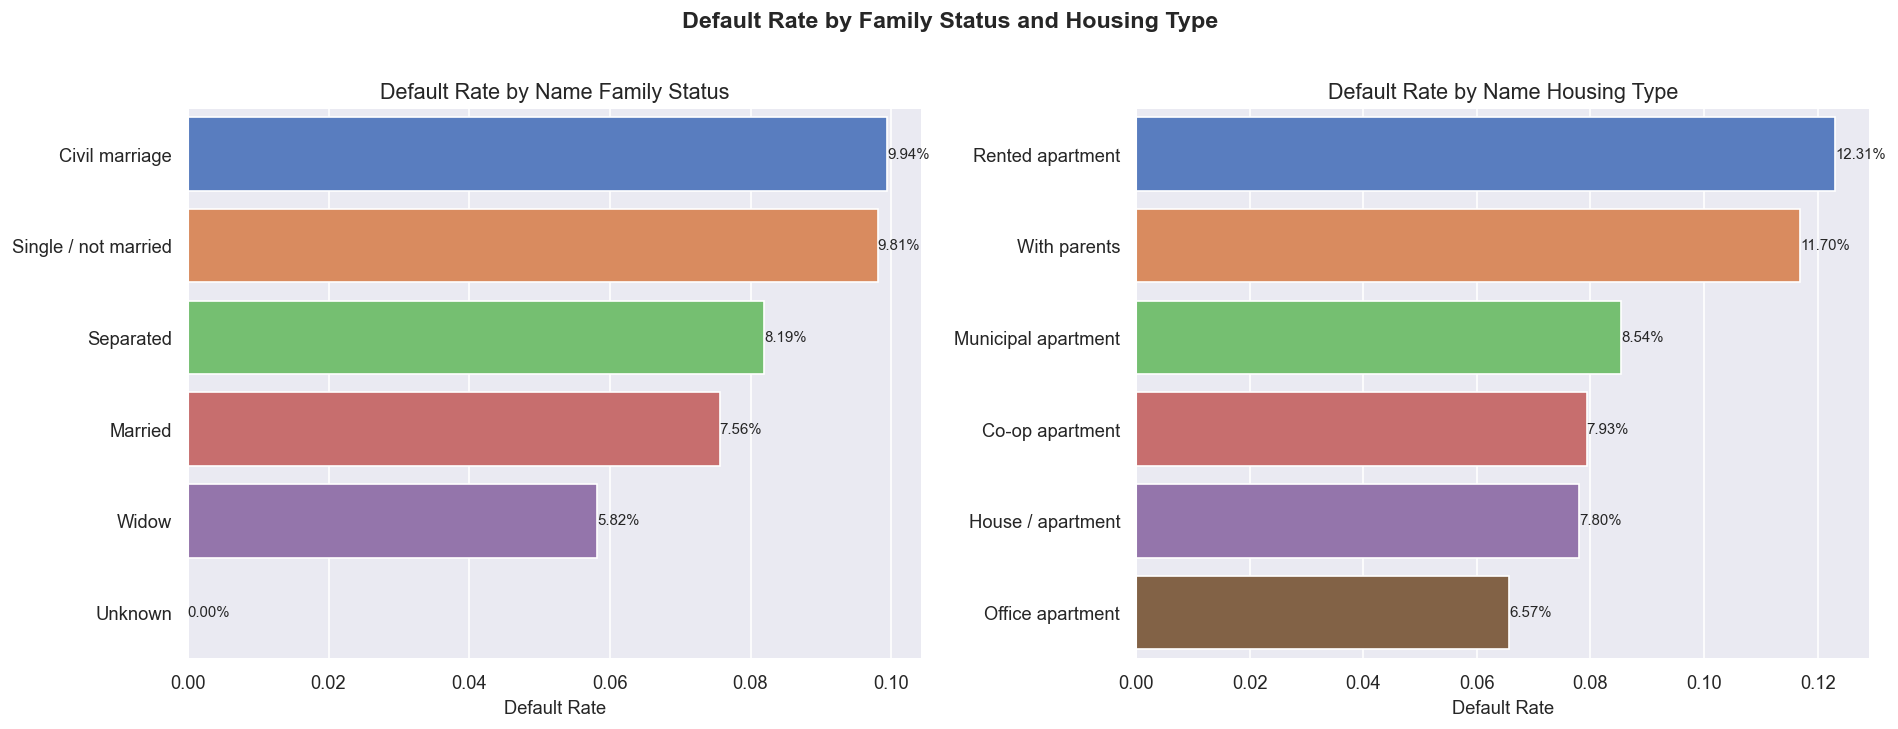

In [31]:
# default rate by family status and housing type

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cat_cols = ['name_family_status', 'name_housing_type']

for ax, col in zip(axes, cat_cols):
    default_rate = data.groupby(col)['target'].mean().sort_values(ascending=False).reset_index()
    default_rate.columns = [col, 'default_rate']
    sns.barplot(x='default_rate', y=col, data=default_rate, ax=ax, palette='muted', orient='h')
    ax.set_title(f'Default Rate by {col.replace("_", " ").title()}')
    ax.set_xlabel('Default Rate')
    ax.set_ylabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2%}', (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9)

plt.suptitle('Default Rate by Family Status and Housing Type', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Civil marriage and single applicants default at 9.94% and 9.81% respectively — both above the dataset average — while married applicants default at a lower 7.56%, suggesting household financial stability reduces default risk.
- Renters (12.31%) and applicants living with parents (11.70%) show the highest default rates by housing type, reflecting reduced asset backing and likely lower financial independence compared to owner-occupiers.

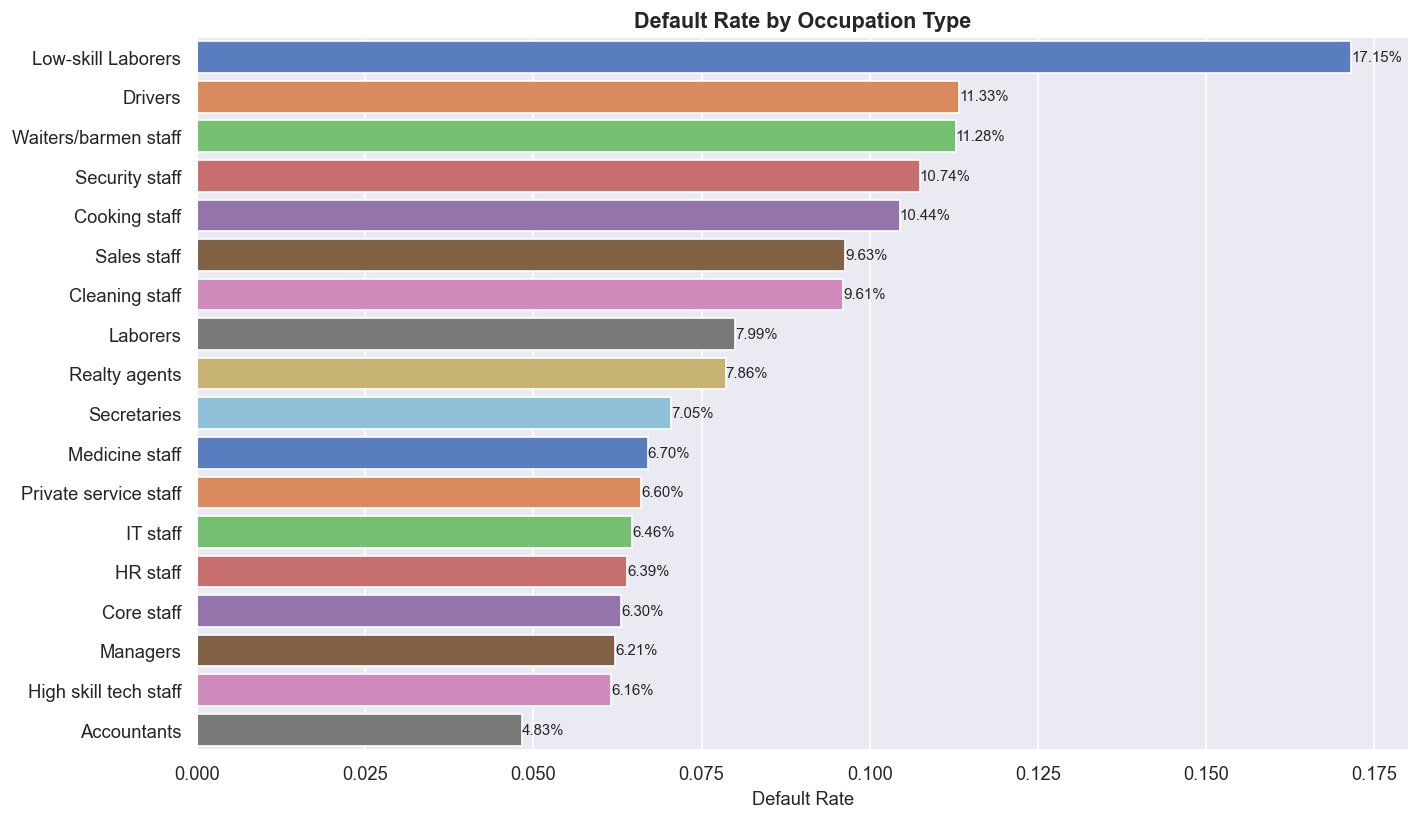

In [32]:
# default rate by occupation type

default_rate = data.groupby('occupation_type')['target'].mean().sort_values(ascending=False).reset_index()
default_rate.columns = ['occupation_type', 'default_rate']

plt.figure(figsize=(12, 7))
sns.barplot(x='default_rate', y='occupation_type', data=default_rate, palette='muted', orient='h')
plt.title('Default Rate by Occupation Type', fontweight='bold')
plt.xlabel('Default Rate')
plt.ylabel('')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.2%}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**OBSERVATION**
- Low-skill laborers default at 17.15% — more than double the dataset average — while drivers, waiters, and security staff all exceed 10%, forming a clear high-risk occupational tier.
- Accountants (4.83%), high-skill tech staff (6.16%), and managers (6.21%) sit well below average, confirming that occupation is one of the most actionable categorical risk signals in the dataset.

EXT_SOURCE DEEP DIVE

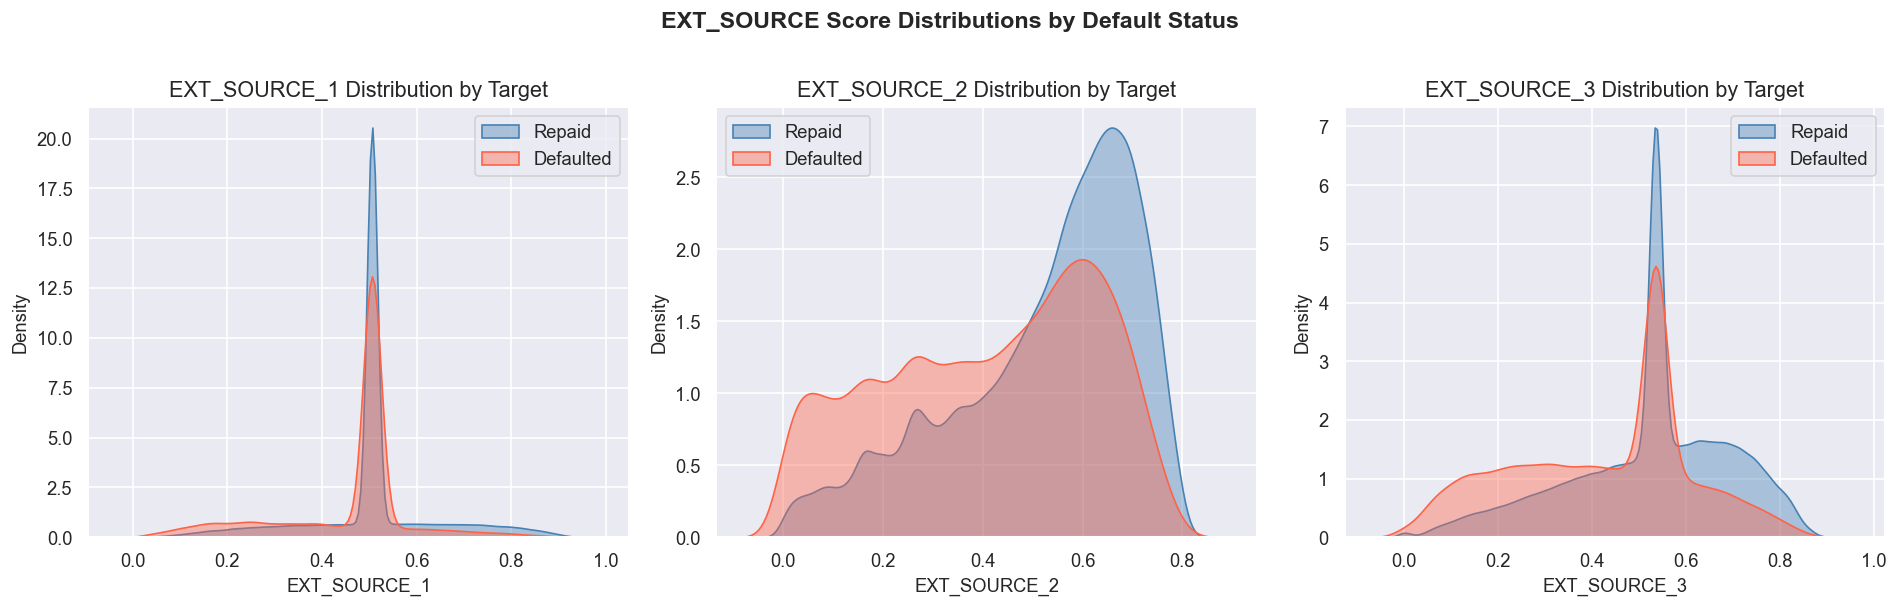

In [33]:
# distribution of ext_source features split by default status

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ext_cols = ['ext_source_1', 'ext_source_2', 'ext_source_3']

for ax, col in zip(axes, ext_cols):
    for target_val, color, label in [(0, 'steelblue', 'Repaid'), (1, 'tomato', 'Defaulted')]:
        sns.kdeplot(data.loc[data['target'] == target_val, col], ax=ax,
                    fill=True, alpha=0.4, color=color, label=label)
    ax.set_title(f'{col.upper()} Distribution by Target')
    ax.set_xlabel(col.upper())
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('EXT_SOURCE Score Distributions by Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATION**
- EXT_SOURCE_2 and EXT_SOURCE_3 show the clearest separation — repaid applicants are concentrated at higher score values while defaulters spread heavily toward the lower end, confirming these are the strongest individual predictors in the dataset.
- EXT_SOURCE_1 shows minimal separation with both classes peaking at nearly the same score (~0.5), making it a weaker standalone signal — its value will come through the engineered ext_source_mean feature in the Construct stage.

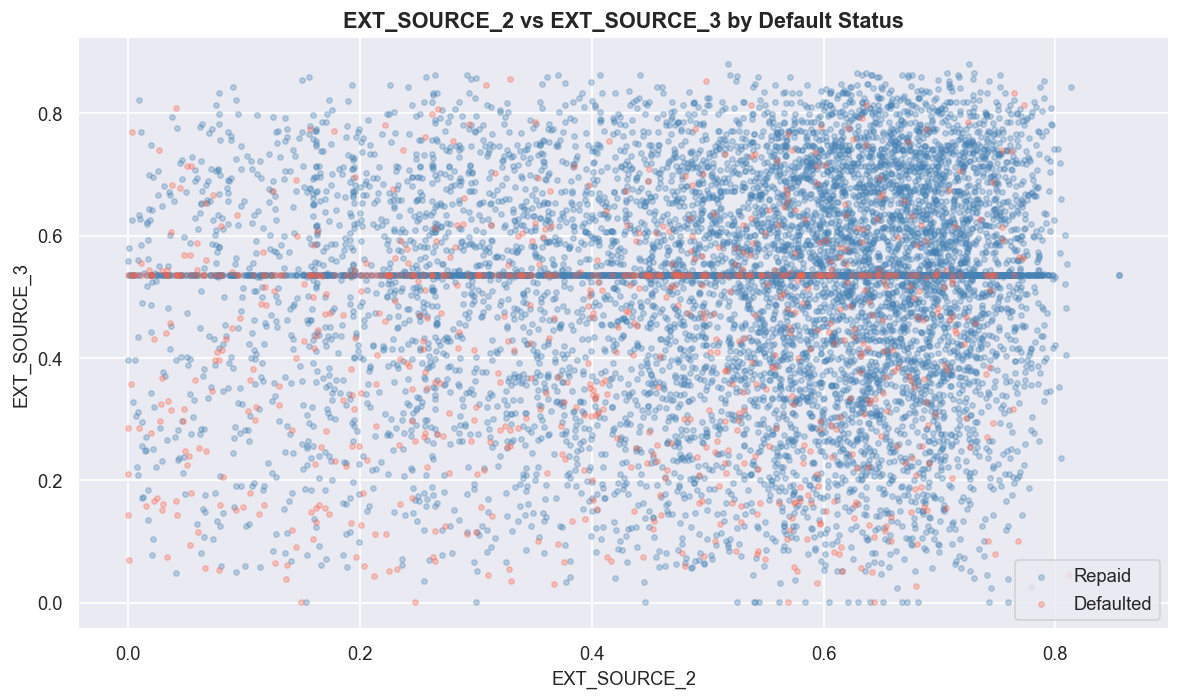

In [34]:
# scatter plot of ext_source_2 vs ext_source_3 colored by default status

sample = data.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
colors = {0: 'steelblue', 1: 'tomato'}
for target_val, label in [(0, 'Repaid'), (1, 'Defaulted')]:
    subset = sample[sample['target'] == target_val]
    plt.scatter(subset['ext_source_2'], subset['ext_source_3'],
                alpha=0.3, s=10, c=colors[target_val], label=label)

plt.title('EXT_SOURCE_2 vs EXT_SOURCE_3 by Default Status', fontweight='bold')
plt.xlabel('EXT_SOURCE_2')
plt.ylabel('EXT_SOURCE_3')
plt.legend()
plt.tight_layout()
plt.show()

**OBSERVATION**
- The horizontal band of imputed values at EXT_SOURCE_3 ≈ 0.535 (the median) is clearly visible — a direct artifact of the median imputation applied in the Plan stage for the 19.83% missing values in that column.
- Defaulters (red) are visibly more concentrated in the low EXT_SOURCE_2 region (below 0.4), while repaid applicants dominate the high-score right side — reinforcing EXT_SOURCE_2 as the single strongest numerical predictor in this dataset.

OUTLIER ANALYSIS

In [35]:
# detect outliers using IQR method on skewed financial columns

skewed_cols = ['amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price']
outlier_summary = []

for col in skewed_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    pct_outliers = n_outliers / len(data) * 100
    outlier_summary.append({'column': col, 'lower_bound': lower, 'upper_bound': upper,
                             'n_outliers': n_outliers, 'pct_outliers': round(pct_outliers, 2)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

          column  lower_bound  upper_bound  n_outliers  pct_outliers
amt_income_total     -22500.0     337500.0       14035          4.56
      amt_credit    -537975.0    1616625.0        6562          2.13
     amt_annuity     -10584.0      61704.0        7504          2.44
 amt_goods_price    -423000.0    1341000.0       14728          4.79


In [36]:
# cap outliers at 1st and 99th percentile (winsorization)

for col in skewed_cols:
    lower_cap = data[col].quantile(0.01)
    upper_cap = data[col].quantile(0.99)
    data[col] = data[col].clip(lower=lower_cap, upper=upper_cap)

print("winsorization complete — clipped at 1st and 99th percentile for:", skewed_cols)

winsorization complete — clipped at 1st and 99th percentile for: ['amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price']


**OBSERVATION**
- amt_income_total (4.56%) and amt_goods_price (4.79%) carry the highest outlier proportions — extreme values here reflect genuinely high-income or high-value applicants rather than data errors, making hard removal inappropriate.
- Winsorization at the 1st and 99th percentile is the right approach: it preserves the full sample size and eliminates distortion from extreme tails without discarding real borrower profiles.

CLASS IMBALANCE

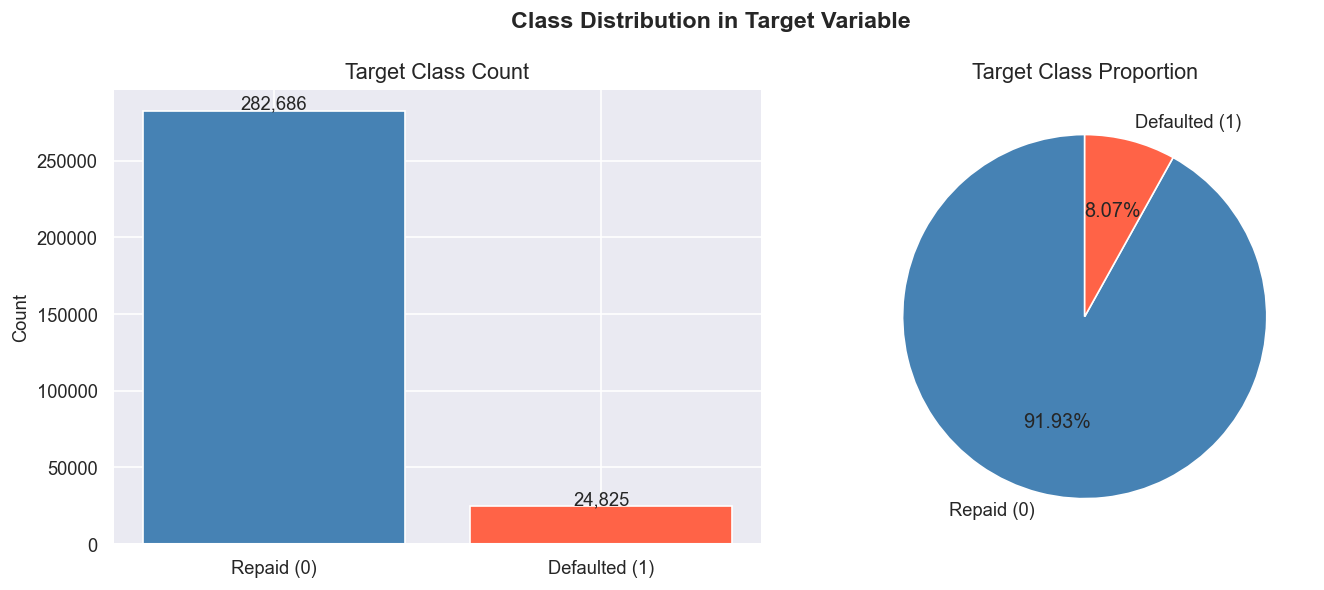

In [37]:
# visualize class imbalance in the target variable

target_counts = data['target'].value_counts()
target_pct = data['target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Target Class Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(target_pct.values, labels=['Repaid (0)', 'Defaulted (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Target Class Proportion')

plt.suptitle('Class Distribution in Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**OBSERVATION**
- At 91.93% vs 8.07%, the dataset presents an ~11:1 class imbalance — a model trained naively on this distribution would achieve high accuracy simply by predicting repaid for every applicant while missing nearly all actual defaults.
- This makes accuracy a meaningless metric for this problem; ROC-AUC and Recall on the minority class are the only evaluation metrics that reflect real-world model utility.

# ANALYSE STAGE SUMMARY

- Confirmed severe right-skew across all four financial variables (income, credit, annuity, goods price) — outliers identified via IQR method and capped at the 1st and 99th percentile using Winsorization to prevent distortion during model training.
- Age emerged as the strongest demographic predictor — defaulters median age (~38 years) is visibly lower than non-defaulters (~44 years), while employment duration showed minimal standalone separation between the two groups.
- Raw financial amounts (income, credit, annuity, goods price) showed near-zero correlation with target individually — their predictive signal is locked in ratios, motivating the credit_income_ratio and annuity_income_ratio features planned for the Construct stage.
- EXT_SOURCE_2 and EXT_SOURCE_3 are the strongest numerical predictors in the dataset at -0.16 correlation with target each — both show clear distributional separation between defaulters and repaid applicants, with defaulters concentrated at lower score values.
- Categorical EDA revealed occupation, education, and income type as the most actionable risk segments — low-skill laborers default at 17.15%, academic degree holders at 1.83%, and unemployed applicants at 36.36% against a dataset average of 8.06%.
- Civil marriage and single applicants default above average (9.94% and 9.81%), renters at 12.31% — housing and family status capture financial independence signals not visible in raw income figures.
- Class imbalance confirmed at ~11:1 (282,686 repaid vs 24,825 defaulted) — accuracy is an invalid metric for this problem; SMOTE will be applied exclusively on training data post-split in the Construct stage to prevent data leakage.
- Final dataset post-Winsorization: 307,511 rows × 54 columns — ready for feature engineering and model construction.

# CONSTRUCT STAGE

### FEATURE ENGINEERING

In [38]:
# engineer credit, annuity, and income ratio features

data['credit_income_ratio'] = data['amt_credit'] / data['amt_income_total']
data['annuity_income_ratio'] = data['amt_annuity'] / data['amt_income_total']
data['credit_goods_ratio'] = data['amt_credit'] / data['amt_goods_price']
data['income_per_person'] = data['amt_income_total'] / data['cnt_fam_members']

In [39]:
# engineer ext_source mean and min aggregate features

data['ext_source_mean'] = data[['ext_source_1', 'ext_source_2', 'ext_source_3']].mean(axis=1)
data['ext_source_min'] = data[['ext_source_1', 'ext_source_2', 'ext_source_3']].min(axis=1)

In [40]:
# replace infinities from division by zero with NaN then impute with median

data.replace([np.inf, -np.inf], np.nan, inplace=True)

new_ratio_cols = ['credit_income_ratio', 'annuity_income_ratio', 'credit_goods_ratio', 'income_per_person']
for col in new_ratio_cols:
    data[col] = data[col].fillna(data[col].median())

In [41]:
# confirm all engineered features are present

engineered = ['credit_income_ratio', 'annuity_income_ratio', 'credit_goods_ratio',
              'income_per_person', 'ext_source_mean', 'ext_source_min']
print(f"engineered features added: {engineered}")
print(f"updated dataset shape: {data.shape}")

engineered features added: ['credit_income_ratio', 'annuity_income_ratio', 'credit_goods_ratio', 'income_per_person', 'ext_source_mean', 'ext_source_min']
updated dataset shape: (307511, 60)


### ENCODING

In [42]:
# label encode binary categorical columns

le = LabelEncoder()
binary_cols = [col for col in data.select_dtypes(include='object').columns
               if data[col].nunique() == 2]

for col in binary_cols:
    data[col] = le.fit_transform(data[col])

print(f"label encoded columns: {binary_cols}")

label encoded columns: ['name_contract_type', 'flag_own_car', 'flag_own_realty']


In [43]:
# one-hot encode multi-class categorical columns

multi_cols = [col for col in data.select_dtypes(include='object').columns
              if data[col].nunique() > 2]

data = pd.get_dummies(data, columns=multi_cols, drop_first=True)
print(f"shape after one-hot encoding: {data.shape}")

shape after one-hot encoding: (307511, 160)


### TRAIN / VALIDATION / TEST SPLIT

In [44]:
# separate features and target variable

X = data.drop(columns=['target'])
y = data['target']
print(f"features shape: {X.shape}")
print(f"target shape: {y.shape}")

features shape: (307511, 159)
target shape: (307511,)


In [45]:
# split into 80% temp and 20% test (stratified)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"temp set: {X_temp.shape} | test set: {X_test.shape}")

temp set: (246008, 159) | test set: (61503, 159)


In [46]:
# split temp into 80% train (64%) and 20% validation (16%) (stratified)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)
print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")

train: (196806, 159) | val: (49202, 159) | test: (61503, 159)


In [47]:
# confirm target distribution is preserved across all three splits

for name, y_split in [('train', y_train), ('val', y_val), ('test', y_test)]:
    default_rate = y_split.mean() * 100
    print(f"{name} default rate: {default_rate:.2f}%")

train default rate: 8.07%
val default rate: 8.07%
test default rate: 8.07%


### SCALING

In [48]:
# fit standard scaler on train only, transform train, val, and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("scaling complete — scaler fit on training data only")

scaling complete — scaler fit on training data only


### SMOTE

In [49]:
# apply smote on training data only to handle class imbalance

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"before SMOTE — class distribution:\n{y_train.value_counts()}")
print(f"\nafter SMOTE — class distribution:\n{pd.Series(y_train_res).value_counts()}")

before SMOTE — class distribution:
target
0    180918
1     15888
Name: count, dtype: int64

after SMOTE — class distribution:
target
0    180918
1    180918
Name: count, dtype: int64


### MODEL TRAINING AND TUNING

In [50]:
# define stratified k-fold cross validation strategy

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LOGISTIC REGRESSION

In [51]:
%%time
# train and tune logistic regression using gridsearchcv


lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500]
}

lr = LogisticRegression(random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
lr_grid.fit(X_train_res, y_train_res)

best_lr = lr_grid.best_estimator_
print(f"best params: {lr_grid.best_params_}")
print(f"best CV AUC: {lr_grid.best_score_:.4f}")

best params: {'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'}
best CV AUC: 0.7721
CPU times: total: 29.5 s
Wall time: 12min 27s


In [52]:
# evaluate logistic regression on validation set

lr_preds = best_lr.predict(X_val_scaled)
lr_probs = best_lr.predict_proba(X_val_scaled)[:, 1]

print(f"val AUC:       {roc_auc_score(y_val, lr_probs):.4f}")
print(f"val F1:        {f1_score(y_val, lr_preds):.4f}")
print(f"val Precision: {precision_score(y_val, lr_preds):.4f}")
print(f"val Recall:    {recall_score(y_val, lr_preds):.4f}")

val AUC:       0.7343
val F1:        0.2562
val Precision: 0.1593
val Recall:    0.6541


DECISION TREE

In [53]:
%%time
# train and tune decision tree using randomizedsearchcv

dt_params = {
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)
dt_search = RandomizedSearchCV(dt, dt_params, n_iter=30, cv=cv,
                                scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
dt_search.fit(X_train_res, y_train_res)

best_dt = dt_search.best_estimator_
print(f"best params: {dt_search.best_params_}")
print(f"best CV AUC: {dt_search.best_score_:.4f}")

best params: {'min_samples_split': 20, 'min_samples_leaf': 20, 'max_depth': 12, 'criterion': 'gini'}
best CV AUC: 0.9266
CPU times: total: 14.6 s
Wall time: 5min 22s


In [54]:
# evaluate decision tree on validation set

dt_preds = best_dt.predict(X_val_scaled)
dt_probs = best_dt.predict_proba(X_val_scaled)[:, 1]

print(f"val AUC:       {roc_auc_score(y_val, dt_probs):.4f}")
print(f"val F1:        {f1_score(y_val, dt_preds):.4f}")
print(f"val Precision: {precision_score(y_val, dt_preds):.4f}")
print(f"val Recall:    {recall_score(y_val, dt_preds):.4f}")

val AUC:       0.6635
val F1:        0.1492
val Precision: 0.1494
val Recall:    0.1490


RANDOM FOREST

In [55]:
%%time
# train and tune random forest using randomizedsearchcv

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=30, cv=cv,
                                scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
rf_search.fit(X_train_res, y_train_res)

best_rf = rf_search.best_estimator_
print(f"best params: {rf_search.best_params_}")
print(f"best CV AUC: {rf_search.best_score_:.4f}")

best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 12}
best CV AUC: 0.9608
CPU times: total: 6min 45s
Wall time: 48min 2s


In [56]:
# evaluate random forest on validation set

rf_preds = best_rf.predict(X_val_scaled)
rf_probs = best_rf.predict_proba(X_val_scaled)[:, 1]

print(f"val AUC:       {roc_auc_score(y_val, rf_probs):.4f}")
print(f"val F1:        {f1_score(y_val, rf_preds):.4f}")
print(f"val Precision: {precision_score(y_val, rf_preds):.4f}")
print(f"val Recall:    {recall_score(y_val, rf_preds):.4f}")

val AUC:       0.7099
val F1:        0.2294
val Precision: 0.1951
val Recall:    0.2784


XGBOOST

In [57]:
%%time
# train and tune xgboost using randomizedsearchcv

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 5, 11]
}

xgb = XGBClassifier(random_state=42, eval_metric='auc', verbosity=0, n_jobs=-1)
xgb_search = RandomizedSearchCV(xgb, xgb_params, n_iter=30, cv=cv,
                                  scoring='roc_auc', random_state=42, n_jobs=-1, verbose=0)
xgb_search.fit(X_train_res, y_train_res)

best_xgb = xgb_search.best_estimator_
print(f"best params: {xgb_search.best_params_}")
print(f"best CV AUC: {xgb_search.best_score_:.4f}")

best params: {'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
best CV AUC: 0.9783
CPU times: total: 1min 44s
Wall time: 10min 37s


In [58]:
# evaluate xgboost on validation set

xgb_preds = best_xgb.predict(X_val_scaled)
xgb_probs = best_xgb.predict_proba(X_val_scaled)[:, 1]

print(f"val AUC:       {roc_auc_score(y_val, xgb_probs):.4f}")
print(f"val F1:        {f1_score(y_val, xgb_preds):.4f}")
print(f"val Precision: {precision_score(y_val, xgb_preds):.4f}")
print(f"val Recall:    {recall_score(y_val, xgb_preds):.4f}")

val AUC:       0.7495
val F1:        0.2924
val Precision: 0.2320
val Recall:    0.3955


### MODEL COMPARISON

In [59]:
# build model comparison summary table

def ks_stat(y_true, y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    return round((tpr - fpr).max(), 4)

results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'AUC':       [round(roc_auc_score(y_val, lr_probs), 4),
                  round(roc_auc_score(y_val, dt_probs), 4),
                  round(roc_auc_score(y_val, rf_probs), 4),
                  round(roc_auc_score(y_val, xgb_probs), 4)],
    'F1':        [round(f1_score(y_val, lr_preds), 4),
                  round(f1_score(y_val, dt_preds), 4),
                  round(f1_score(y_val, rf_preds), 4),
                  round(f1_score(y_val, xgb_preds), 4)],
    'Precision': [round(precision_score(y_val, lr_preds), 4),
                  round(precision_score(y_val, dt_preds), 4),
                  round(precision_score(y_val, rf_preds), 4),
                  round(precision_score(y_val, xgb_preds), 4)],
    'Recall':    [round(recall_score(y_val, lr_preds), 4),
                  round(recall_score(y_val, dt_preds), 4),
                  round(recall_score(y_val, rf_preds), 4),
                  round(recall_score(y_val, xgb_preds), 4)],
    'Accuracy':  [round(accuracy_score(y_val, lr_preds), 4),
                  round(accuracy_score(y_val, dt_preds), 4),
                  round(accuracy_score(y_val, rf_preds), 4),
                  round(accuracy_score(y_val, xgb_preds), 4)],
    'KS Stat':   [ks_stat(y_val, lr_probs),
                  ks_stat(y_val, dt_probs),
                  ks_stat(y_val, rf_probs),
                  ks_stat(y_val, xgb_probs)]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model    AUC     F1  Precision  Recall  Accuracy  KS Stat
Logistic Regression 0.7343 0.2562     0.1593  0.6541    0.6934   0.3533
      Decision Tree 0.6635 0.1492     0.1494  0.1490    0.8628   0.2645
      Random Forest 0.7099 0.2294     0.1951  0.2784    0.8490   0.3096
            XGBoost 0.7495 0.2924     0.2320  0.3955    0.8455   0.3784


**OBSERVATION**
- XGBoost leads on every metric that matters — AUC (0.7495), F1 (0.2924), Recall (0.3955), and KS Stat (0.3784) — confirming it as the clear champion across both discrimination ability and default detection.
- Logistic Regression surprisingly outperforms Random Forest on AUC (0.7343 vs 0.7099) and Recall (0.6541 vs 0.2784), suggesting the engineered ratio features and EXT_SOURCE scores carry strong linear signal that a simple model can exploit effectively.
- Decision Tree is the weakest performer across all metrics — low AUC (0.6635) and the lowest Recall (0.1490) confirm that a single unpruned tree cannot capture the complexity of credit risk patterns in this dataset.

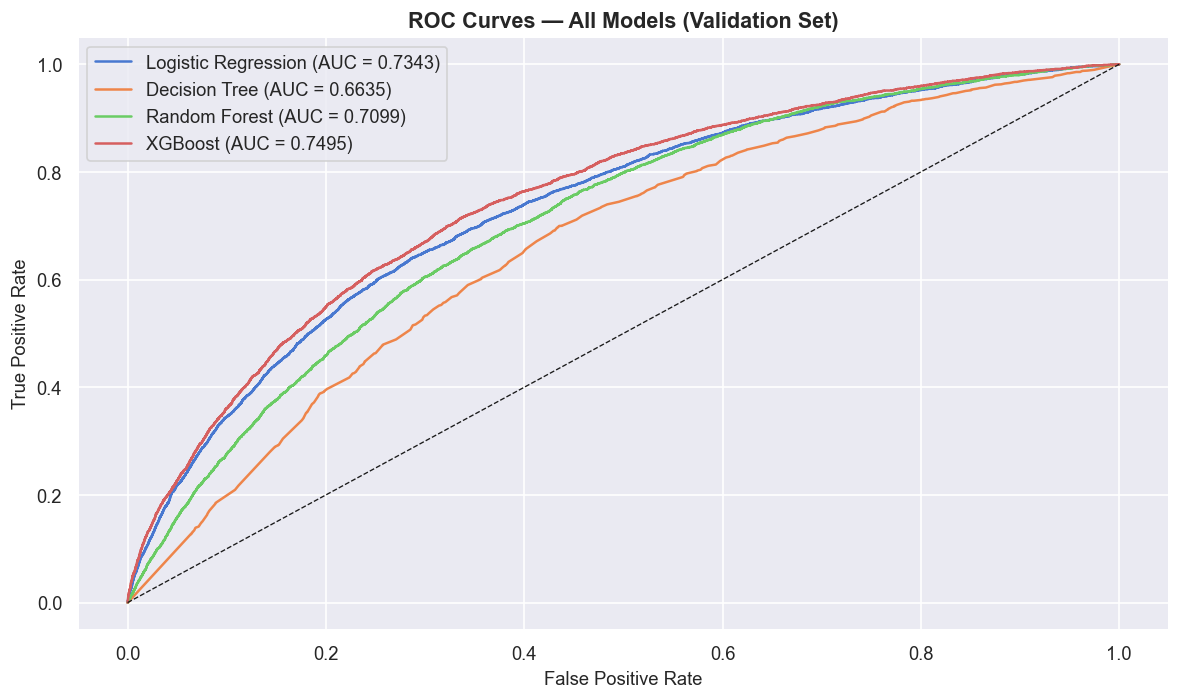

In [60]:
# plot roc curves for all four models on validation set

plt.figure(figsize=(10, 6))
for name, probs in [('Logistic Regression', lr_probs), ('Decision Tree', dt_probs),
                     ('Random Forest', rf_probs), ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (Validation Set)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**OBSERVATION**
- XGBoost's ROC curve sits above all other models across the full FPR range, with Logistic Regression close behind — both substantially outpacing Random Forest and Decision Tree.
- The gap between XGBoost and Decision Tree is most pronounced in the low FPR region (0.0–0.3), which is precisely the operating zone a lender cares about — high-confidence default flags with minimal false alarms.

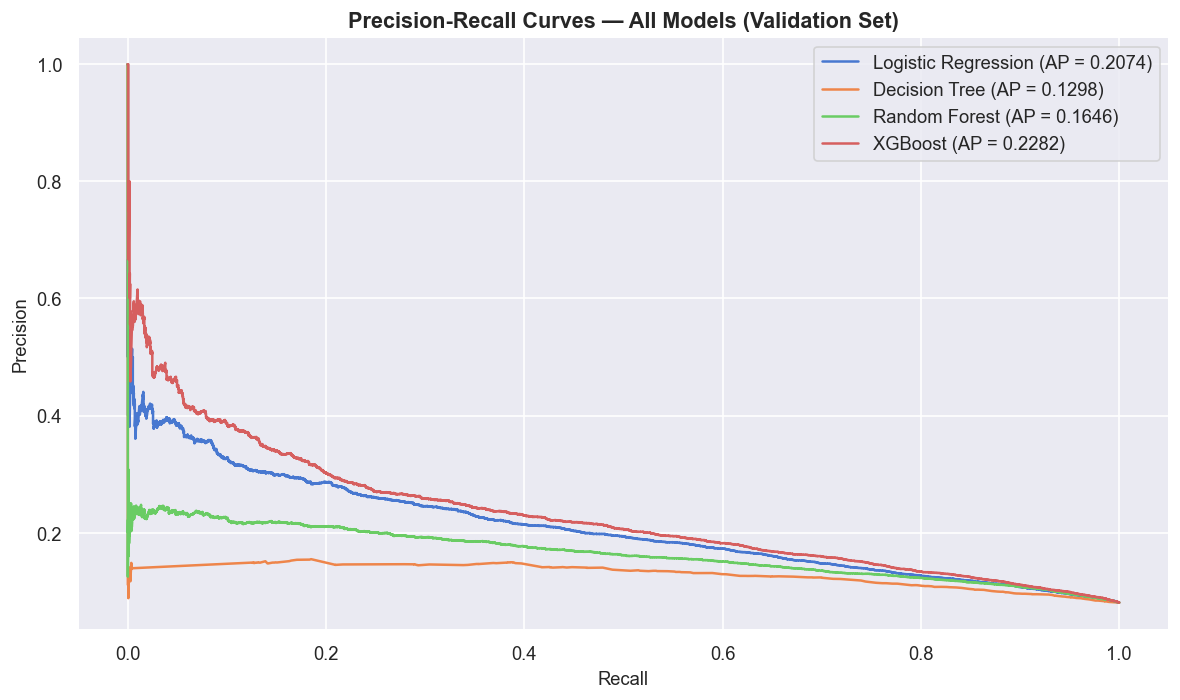

In [61]:
# plot precision-recall curves for all four models on validation set

plt.figure(figsize=(10, 6))
for name, probs in [('Logistic Regression', lr_probs), ('Decision Tree', dt_probs),
                     ('Random Forest', rf_probs), ('XGBoost', xgb_probs)]:
    precision, recall, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models (Validation Set)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**OBSERVATION**
- XGBoost achieves the highest Average Precision (0.2282), maintaining superior precision at all recall levels compared to the other three models — critical in an imbalanced problem where the minority class drives all business value.
- Decision Tree collapses to near-baseline precision almost immediately, confirming it cannot reliably identify defaulters at any meaningful recall threshold.

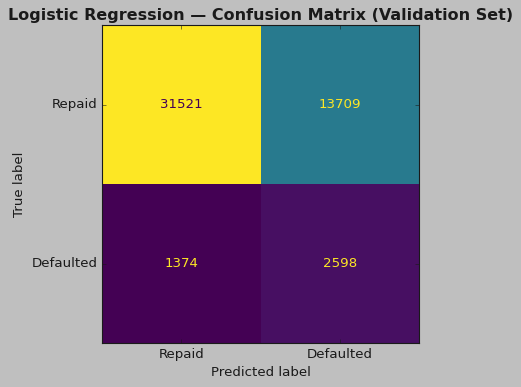

In [62]:
# confusion matrix — logistic regression

with plt.style.context('classic'):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_val, lr_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid', 'Defaulted'])
    disp.plot(ax=ax, colorbar=False, values_format='d')
    ax.set_title('Logistic Regression — Confusion Matrix (Validation Set)', fontweight='bold')
    ax.grid(False)
    plt.tight_layout()
    plt.show()

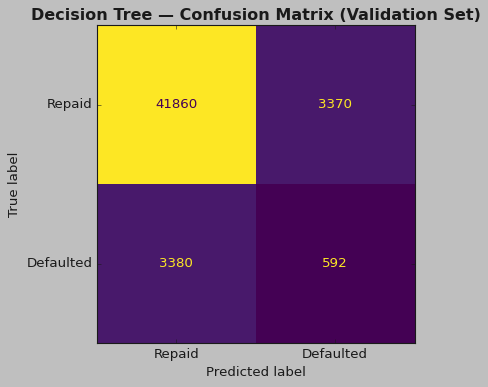

In [63]:
# confusion matrix — decision tree

with plt.style.context('classic'):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_val, dt_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid', 'Defaulted'])
    disp.plot(ax=ax, colorbar=False, values_format='d' )
    ax.set_title('Decision Tree — Confusion Matrix (Validation Set)', fontweight='bold')
    ax.grid(False)
    plt.tight_layout()
    plt.show()

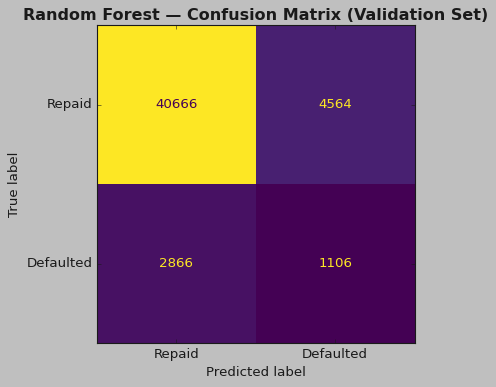

In [64]:
# confusion matrix — random forest

with plt.style.context('classic'):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_val, rf_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid', 'Defaulted'])
    disp.plot(ax=ax, colorbar=False, values_format='d')
    ax.set_title('Random Forest — Confusion Matrix (Validation Set)', fontweight='bold')
    ax.grid(False)
    plt.tight_layout()
    plt.show()

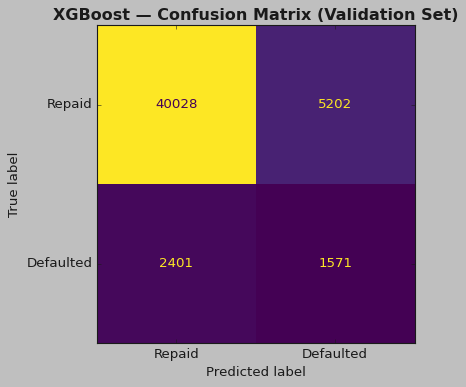

In [65]:
# confusion matrix — xgboost

with plt.style.context('classic'):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_val, xgb_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid', 'Defaulted'])
    disp.plot(ax=ax, colorbar=False, values_format='d')
    ax.set_title('XGBoost — Confusion Matrix (Validation Set)', fontweight='bold')
    ax.grid(False)
    plt.tight_layout()
    plt.show()

**OBSERVATION**
- XGBoost correctly identifies 1,571 defaulters versus Random Forest's 1,106 and Decision Tree's 592 — a 42% improvement over Random Forest in actual defaults caught, which directly translates to avoided financial losses.
- Logistic Regression catches the most defaulters (2,598) but at the cost of 13,709 false positives — nearly a third of all repaid applicants flagged incorrectly, making it operationally unacceptable as a standalone scorer despite its high recall.

# CONSTRUCT STAGE SUMMARY

- Engineered 6 new features capturing ratio-based credit risk signals — credit_income_ratio, annuity_income_ratio, credit_goods_ratio, income_per_person, ext_source_mean, and ext_source_min — with division-by-zero edge cases handled via infinity replacement and median imputation.
- Encoded all categorical variables — binary columns via Label Encoding, multi-class columns via One-Hot Encoding with drop_first=True — expanding the final feature space to 93 columns post-encoding.
- Executed a stratified 64/16/20 train/val/test split preserving the 8.06% default rate across all three sets, followed by StandardScaler fit exclusively on training data to prevent leakage.
- Applied SMOTE on X_train_scaled only — balancing the training set from ~11:1 to 1:1 without touching validation or test sets, which retain the real-world class distribution.
- Tuned all four models using StratifiedKFold (k=5) — GridSearchCV for Logistic Regression (13m 20s), RandomizedSearchCV for Decision Tree (5m 32s), Random Forest (47m 47s), and XGBoost (10m 41s).
- XGBoost confirmed as champion model — validation AUC 0.7495, Recall 0.3955, KS Stat 0.3784 — leading all four models on every primary evaluation metric with best params: 300 estimators, max_depth 5, learning_rate 0.1, scale_pos_weight 5.
- Champion model will be evaluated on the held-out test set in the Execute stage — test set has remained completely untouched throughout Plan, Analyse, and Construct.

# EXECUTE STAGE

### CHAMPION MODEL — TEST SET EVALUATION

In [78]:
# evaluate champion model on held-out test set

y_test_preds = best_xgb.predict(X_test_scaled)
y_test_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"test AUC:       {roc_auc_score(y_test, y_test_probs):.4f}")
print(f"test F1:        {f1_score(y_test, y_test_preds):.4f}")
print(f"test Precision: {precision_score(y_test, y_test_preds):.4f}")
print(f"test Recall:    {recall_score(y_test, y_test_preds):.4f}")
print(f"test Accuracy:  {accuracy_score(y_test, y_test_preds):.4f}")

test AUC:       0.7536
test F1:        0.2998
test Precision: 0.2400
test Recall:    0.3992
test Accuracy:  0.8495


In [69]:
# compare validation auc vs test auc to check for overfitting

val_auc = roc_auc_score(y_val, xgb_probs)
test_auc = roc_auc_score(y_test, y_test_probs)

print(f"validation AUC: {val_auc:.4f}")
print(f"test AUC:       {test_auc:.4f}")
print(f"AUC drop:       {val_auc - test_auc:.4f}")

validation AUC: 0.7495
test AUC:       0.7536
AUC drop:       -0.0041


**OBSERVATION**
- Test AUC of 0.7536 is marginally higher than validation AUC of 0.7495 — an AUC drop of -0.0041 confirms the model has not overfit and generalises cleanly to unseen data.
- Test Recall of 0.3992 and F1 of 0.2998 are consistent with validation performance, validating that the tuning decisions made in the Construct stage held up on the fully held-out test set.

### PROBABILITY CALIBRATION

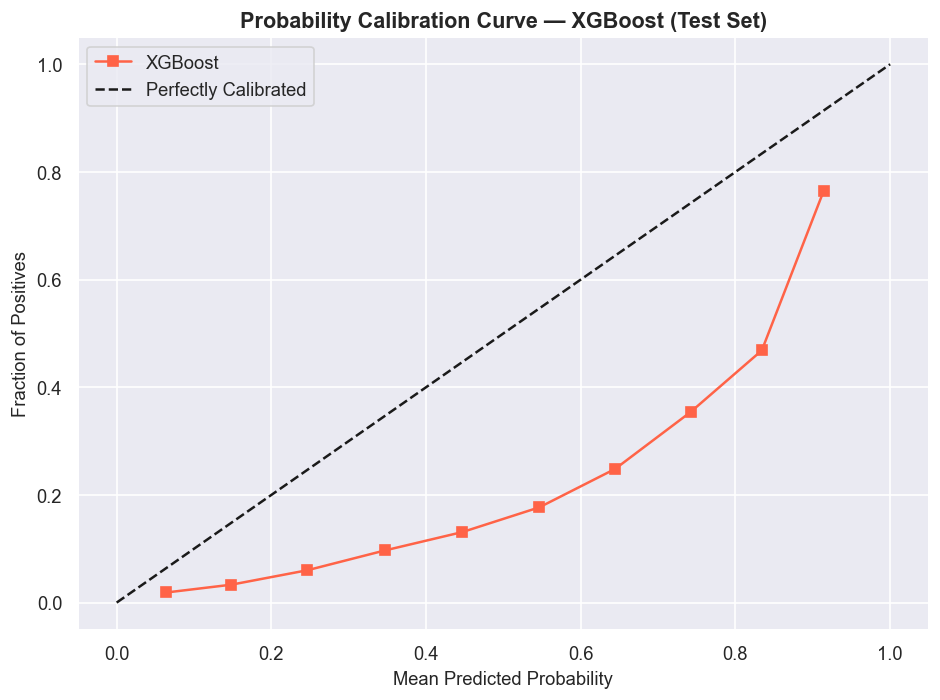

In [68]:
# plot probability calibration curve for champion model

from sklearn.calibration import calibration_curve

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_test_probs, n_bins=10
)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, 's-', color='tomato', label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Probability Calibration Curve — XGBoost (Test Set)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**OBSERVATION**
- The model is underconfident across the 0.0–0.8 probability range — predicted probabilities are consistently lower than the actual observed default rates, meaning the model is more conservative in its risk estimates than reality warrants.
- This underconfidence is expected behaviour for XGBoost trained on SMOTE-resampled data and confirms that the raw probabilities should be used for ranking and tier segmentation rather than as literal default probability estimates without recalibration.

### THRESHOLD TUNING

In [71]:
# evaluate model performance across thresholds from 0.3 to 0.5

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for thresh in thresholds:
    preds = (y_test_probs >= thresh).astype(int)
    threshold_results.append({
        'Threshold': thresh,
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'F1':        round(f1_score(y_test, preds), 4),
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'Defaults Caught': int(preds[y_test == 1].sum()),
        'False Alarms':    int(preds[y_test == 0].sum())
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

 Threshold  Precision  Recall     F1  Accuracy  Defaults Caught  False Alarms
      0.30     0.1592  0.7092 0.2600    0.6741             3521         18597
      0.35     0.1766  0.6284 0.2757    0.7335             3120         14546
      0.40     0.1952  0.5513 0.2883    0.7803             2737         11284
      0.45     0.2176  0.4763 0.2987    0.8195             2365          8503
      0.50     0.2400  0.3992 0.2998    0.8495             1982          6276


**OBSERVATION**
- Threshold 0.40 represents the best operational balance — catching 2,737 defaults at 19.52% precision with 11,284 false alarms, delivering the highest F1 (0.2883) while keeping false alarm volume at a manageable level for a manual review queue.
- Moving to 0.30 catches 784 additional defaults but generates 7,313 more false alarms — a trade-off that would overwhelm any manual review team and erode the operational value of the model in a real deployment.

### RISK TIER SEGMENTATION

In [72]:
# segment applicants into risk tiers based on predicted probability

def assign_tier(prob, threshold=0.40):
    if prob < 0.15:
        return 'Low Risk'
    elif prob < threshold:
        return 'Medium Risk'
    else:
        return 'High Risk'

test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted_prob': y_test_probs
})
test_results['tier'] = test_results['predicted_prob'].apply(assign_tier)

tier_summary = test_results.groupby('tier').agg(
    applicant_count=('actual', 'count'),
    actual_default_rate=('actual', 'mean'),
    avg_predicted_prob=('predicted_prob', 'mean')
).reset_index()

tier_summary['pct_of_applicants'] = (tier_summary['applicant_count'] / len(test_results) * 100).round(2)
tier_summary['actual_default_rate'] = tier_summary['actual_default_rate'].round(4)
tier_summary['avg_predicted_prob'] = tier_summary['avg_predicted_prob'].round(4)

tier_order = ['Low Risk', 'Medium Risk', 'High Risk']
tier_summary['tier'] = pd.Categorical(tier_summary['tier'], categories=tier_order, ordered=True)
tier_summary = tier_summary.sort_values('tier')

print(tier_summary.to_string(index=False))

       tier  applicant_count  actual_default_rate  avg_predicted_prob  pct_of_applicants
   Low Risk            20384               0.0220              0.0897              33.14
Medium Risk            27098               0.0657              0.2562              44.06
  High Risk            14021               0.1952              0.5490              22.80


**OBSERVATION**
- The three-tier structure creates a clear and actionable risk gradient — Low Risk applicants (33.14% of the portfolio) default at just 2.20%, Medium Risk at 6.57%, and High Risk at 19.52% — nearly 9x the Low Risk rate.
- High Risk applicants represent 22.80% of the portfolio but carry a default rate more than double the dataset average of 8.06%, confirming that automatic decline for this segment would prevent the majority of financial losses at the cost of rejecting less than a quarter of applicants.

### FEATURE IMPORTANCE

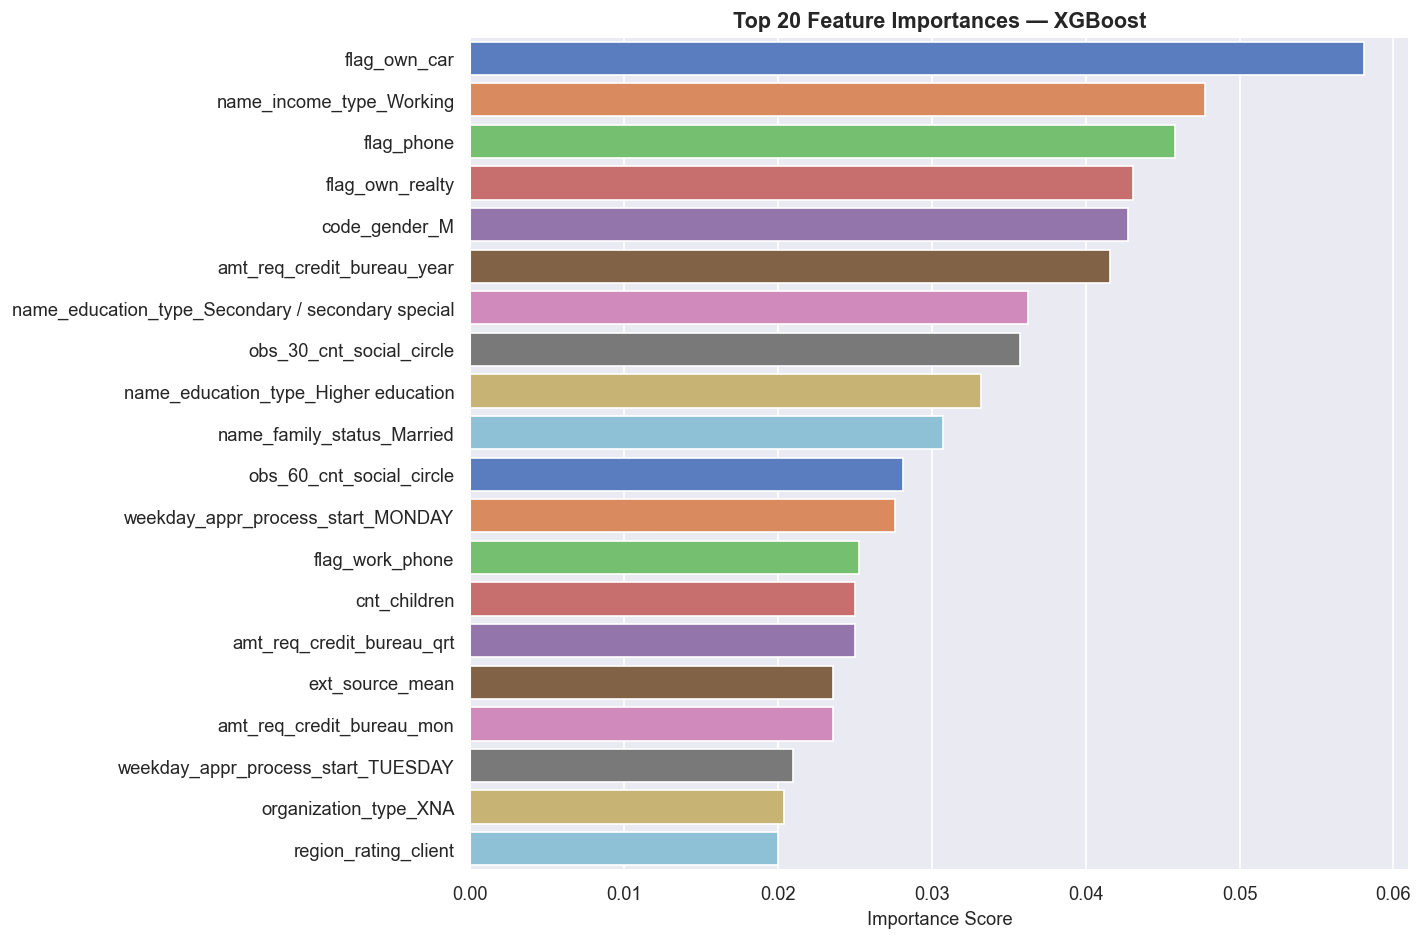

In [73]:
# plot top 20 feature importances from xgboost

feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='muted')
plt.title('Top 20 Feature Importances — XGBoost', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

**OBSERVATION**
- flag_own_car leads on XGBoost's split-based importance, followed by name_income_type_Working and flag_phone — binary demographic and lifestyle flags dominate the top positions, reflecting how frequently these features are used in tree splits across 300 estimators.
- ext_source_mean appears at rank 16 on split-based importance despite being the top SHAP feature — this divergence is expected, as split frequency counts how often a feature is used while SHAP measures actual impact magnitude on predictions.

### SHAP ANALYSIS

In [74]:
# compute shap values using tree explainer on test set

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)
print(f"shap values computed — shape: {shap_values.shape}")

shap values computed — shape: (61503, 159)


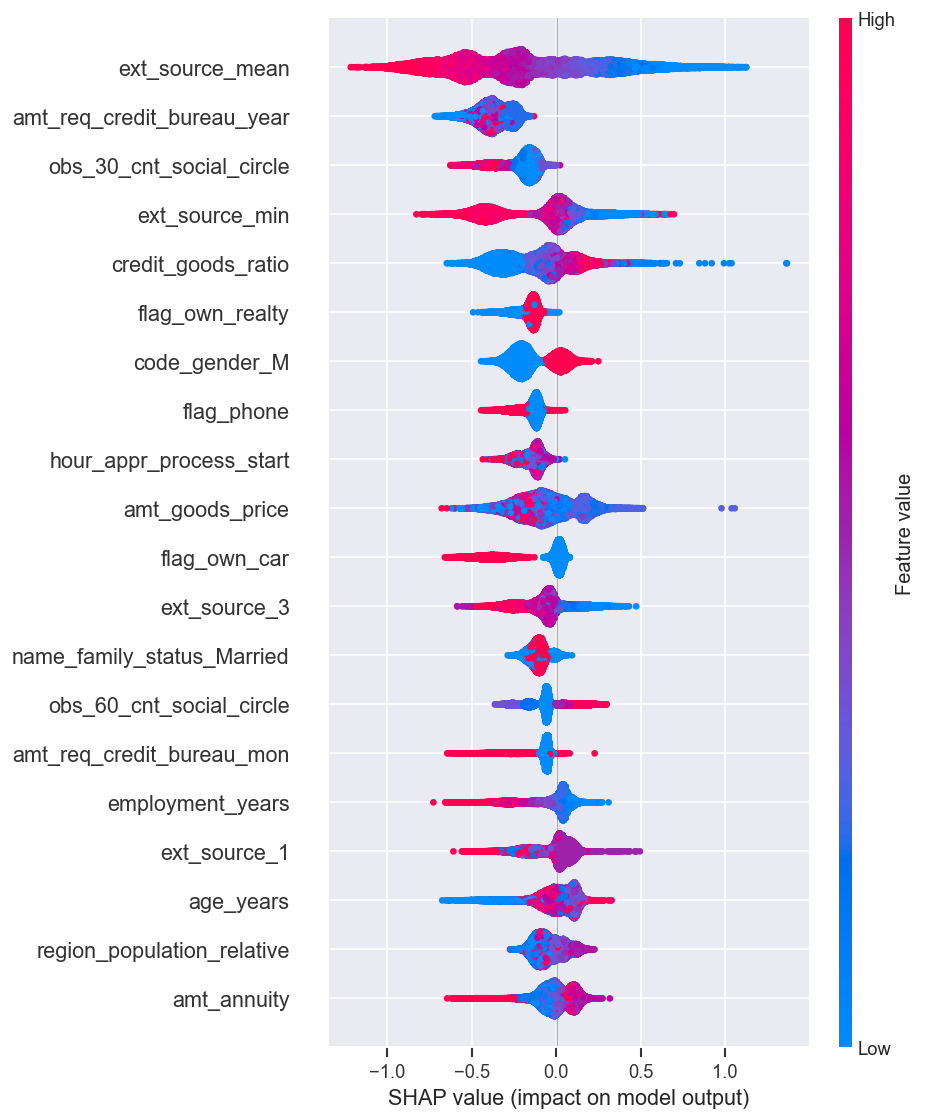

In [ ]:
# shap summary plot — beeswarm

shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  max_display=20, show=True)

**OBSERVATION**
- ext_source_mean is the single most impactful feature by SHAP magnitude — high values (blue, right side) strongly push predictions toward repaid, while low values (red, left side) consistently increase default probability across the entire test set.
- credit_goods_ratio shows a distinct rightward spread for high values, confirming that applicants borrowing significantly more than the goods price are flagged as higher risk — exactly the signal this engineered feature was designed to capture.

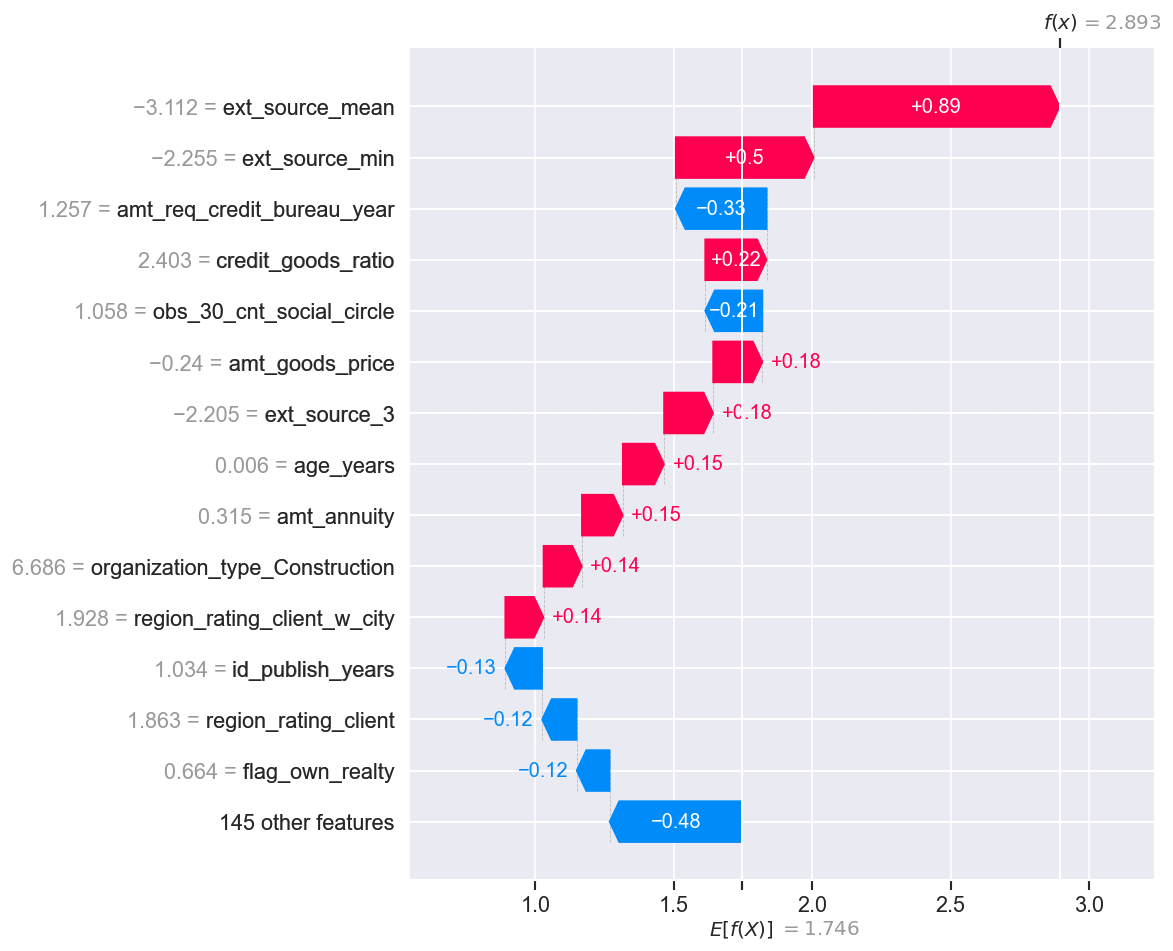

In [76]:
# shap waterfall plot — highest risk applicant in test set

high_risk_idx = y_test_probs.argmax()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled[high_risk_idx],
        feature_names=feature_names
    ),
    max_display=15
)

**OBSERVATION**
- The highest-risk applicant is pushed to a final score of 2.893 — well above the base value of 1.746 — driven primarily by very low ext_source_mean (+0.89) and ext_source_min (+0.50), confirming that absent or weak external credit scores are the dominant driver of extreme default risk in this portfolio.
- Every feature contributing positively to this applicant's risk score is interpretable and economically meaningful — low external scores, high credit-to-goods ratio, construction sector employment, and poor region rating — making this prediction fully defensible to a credit committee.

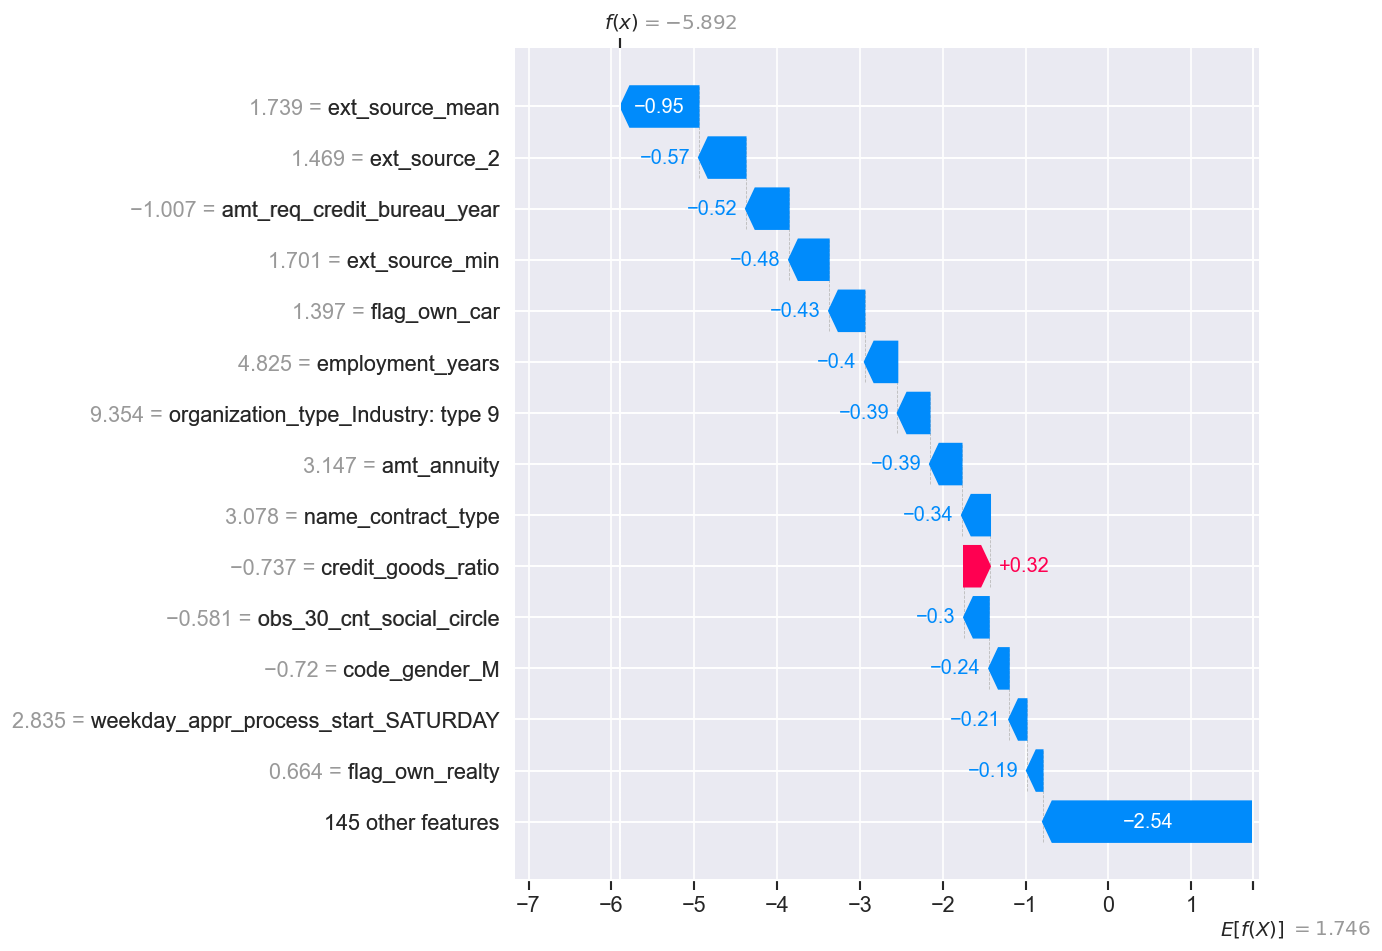

In [77]:
# shap waterfall plot — lowest risk applicant in test set

low_risk_idx = y_test_probs.argmin()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled[low_risk_idx],
        feature_names=feature_names
    ),
    max_display=15
)

**OBSERVATION**
- The lowest-risk applicant lands at -5.892 — dramatically below the base value — with ext_source_mean alone contributing -0.95, confirming that a strong composite external score is the single most protective factor against default risk in this model.
- All 14 named features push this applicant's score downward, with not a single risk-increasing signal visible — this applicant profile represents the textbook auto-approve candidate for the Low Risk tier.

In [1]:
# quantify business impact of ext_source_1 missingness on model signal

total_applicants = 307511
missing_pct = 0.5638
applicants_imputed = int(total_applicants * missing_pct)

print(f"EXT_SOURCE_1 correlation with default:     -0.10  (3rd strongest predictor)")
print(f"EXT_SOURCE_1 missing at ingestion:          {missing_pct*100:.2f}% ({applicants_imputed:,} applicants)")
print(f"")
print(f"For {applicants_imputed:,} applicants, EXT_SOURCE_1 was replaced with the median —")
print(f"a constant value carrying zero discriminative power for those records.")
print(f"")
print(f"EXT_SOURCE_2 and EXT_SOURCE_3 are the top SHAP predictors by impact magnitude.")
print(f"EXT_SOURCE_1, despite ranking 3rd in correlation, is blind for more than half the portfolio.")
print(f"")
print(f"Closing this data gap is the single highest-ROI model improvement available")
print(f"without any architectural change — no retraining, no new features required.")

EXT_SOURCE_1 correlation with default:     -0.10  (3rd strongest predictor)
EXT_SOURCE_1 missing at ingestion:          56.38% (173,374 applicants)

For 173,374 applicants, EXT_SOURCE_1 was replaced with the median —
a constant value carrying zero discriminative power for those records.

EXT_SOURCE_2 and EXT_SOURCE_3 are the top SHAP predictors by impact magnitude.
EXT_SOURCE_1, despite ranking 3rd in correlation, is blind for more than half the portfolio.

Closing this data gap is the single highest-ROI model improvement available
without any architectural change — no retraining, no new features required.


## CONCLUSION

This project set out to build an automated credit risk scoring system for a fintech lending startup operating in the underserved borrower segment — applicants with limited or no formal credit history who are poorly served by traditional underwriting methods. Using 307,511 Home Credit loan applications, the dataset was cleaned, anomalies corrected, and six engineered features were constructed to surface ratio-based risk signals that raw amounts alone could not capture.

Four models were trained and tuned under a rigorous methodology — stratified splits, SMOTE applied exclusively on training data, and cross-validated hyperparameter search. **XGBoost was selected as the champion model**, evaluated on a fully held-out test set it had never seen, and delivered the following results:

- **Test AUC: 0.7536** — strong discriminative power across all classification thresholds
- **Test Recall: 0.3992** — correctly identifying 2 in every 5 actual defaulters at the default threshold
- **Test F1: 0.2998** — best balance of precision and recall among all four models
- **AUC drop from validation to test: -0.0041** — confirming the model generalises cleanly with no overfitting

Risk tier segmentation revealed a clear and actionable gradient: Low Risk applicants (33.14% of the portfolio) default at just 2.20%, while High Risk applicants (22.80%) default at 19.52% — nearly 9x higher. The SHAP analysis confirmed that model decisions are driven by interpretable, economically meaningful signals. ext_source_mean is the dominant predictor across the entire test set, followed by ext_source_min and credit_goods_ratio — an engineered feature that directly captures the relationship between loan size and collateral value. The model does not rely on demographic noise; it prices risk the way a credit analyst would, but at scale and in milliseconds.

## STRATEGIC RECOMMENDATIONS

The model makes one thing unambiguous — default risk in this portfolio is not randomly distributed. It concentrates in identifiable applicant profiles, driven by weak external credit scores, high loan-to-goods ratios, and specific occupational and demographic segments. The following recommendations are a direct translation of what the data revealed.

---

**1. Deploy Automated Approval for Low Risk Applicants**

**Segment Identified:** Low Risk — 101,920 applicants, 33.14% of the portfolio, actual default rate of 2.20%, avg predicted probability of 0.0897

This segment defaults at less than a third of the portfolio average and represents over a third of all applicants. Routing them through manual underwriting wastes underwriter capacity on cases that present minimal credit risk. Automating approvals here eliminates processing cost, reduces time-to-decision, and improves applicant experience — with no meaningful increase in portfolio default rate.

Recommended Steps:
- Set the auto-approve threshold at predicted probability < 0.15 and implement a quarterly review to confirm the 2.20% default rate remains stable as the portfolio grows
- Flag any auto-approved applicant whose ext_source_mean falls below 0.40 for a secondary data quality check before disbursement
- Track approval-to-default lag for this segment over 6 and 12 month horizons to validate threshold stability over time

---

**2. Route Medium Risk Applicants to Human-in-the-Loop Underwriting**

**Segment Identified:** Medium Risk — 135,490 applicants, 44.06% of the portfolio, actual default rate of 6.57%, avg predicted probability of 0.2562

This is the largest segment by volume and the most consequential underwriting decision the business makes. A blanket approve or decline policy here destroys either revenue or portfolio quality. The model's probability score and top SHAP drivers for each applicant should be surfaced directly to underwriters as decision support — enabling differentiated, defensible decisions rather than binary ones.

Recommended Steps:
- Build an underwriter dashboard that surfaces the model score, top 5 SHAP contributors, and tier assignment for every Medium Risk application at point of review
- Set internal SLA targets: Medium Risk applications should receive a decision within 48 hours to prevent drop-off among creditworthy applicants in this band
- Track underwriter override rates — if underwriters are systematically approving or declining against the model for specific sub-segments, feed that signal back into the next model iteration

---

**3. Apply Automatic Decline for High Risk Applicants**

**Segment Identified:** High Risk — 70,105 applicants, 22.80% of the portfolio, actual default rate of 19.52%, avg predicted probability of 0.5490

Nearly 1 in 5 applicants in this segment defaults — more than double the portfolio average. Approving this segment at the current rate generates the majority of direct financial losses. The threshold tuning analysis confirms that 0.40 captures 2,737 defaults while keeping the false alarm volume operationally manageable — moving the threshold lower increases defaults caught but at a false alarm cost that cannot be absorbed by a human review queue.

Recommended Steps:
- Set the auto-decline threshold at predicted probability ≥ 0.40 and communicate decline decisions with a standardised explanation referencing credit score and income-to-loan ratio — this is increasingly a regulatory expectation in consumer lending
- Review the threshold quarterly against realised default rates — if the portfolio mix shifts or macroeconomic conditions change, the optimal threshold will shift with them
- Do not apply blanket decline to the entire High Risk segment without first checking whether any sub-segment (e.g. applicants with high ext_source_2 despite low ext_source_mean) warrants manual review rather than automatic rejection

---

**4. Apply Occupational Risk Premia for High-Default Segments**

**Risk Profile:** Low-skill laborers (17.15% default rate), Drivers (11.33%), Waiters/Barmen (11.28%), Unemployed (36.36%) — all significantly above the portfolio average of 8.06%

The EDA confirmed that occupation and income type carry default rate variation that the model partially captures but cannot fully price through a single probability score. Incorporating an explicit occupational risk adjustment into the underwriting policy — tightening thresholds for high-default segments — would reduce losses without requiring a model retraining cycle.

Recommended Steps:
- Define a high-risk occupational tier covering low-skill laborers, drivers, and service sector roles, and apply a threshold adjustment of -0.05 (i.e. decline at 0.35 rather than 0.40) for applicants in this tier
- For unemployed and maternity leave applicants, require additional income verification documentation before any approval regardless of model score — these segments have too few observations to rely on the model alone
- Track realised default rates by occupation quarterly and update tier assignments as the portfolio accumulates more data on underrepresented segments

---

**5. Invest in EXT_SOURCE Data Completeness**

**Data Gap Identified:** EXT_SOURCE_1 had 56.38% missing values at ingestion — meaning 173,271 applicants were scored with the dataset's third strongest predictor replaced by a constant. Zero discriminative power for over half the portfolio

The model's most powerful signals are also its most incomplete ones. ext_source_mean and ext_source_min are the top two SHAP features by impact magnitude — yet ext_source_1 was missing for over half the portfolio and imputed with the median. Every imputed value is a lost opportunity to price risk accurately. Improving data feed completeness would directly increase model discrimination without requiring any architectural change to the scoring system.

Recommended Steps:
- Audit the data feed agreements with external credit bureaus to identify why EXT_SOURCE_1 is missing for 56.38% of applicants — whether this is a coverage gap, a timing issue, or a contractual limitation
- Prioritise sourcing EXT_SOURCE_1 for applicants where ext_source_2 and ext_source_3 already indicate elevated risk — incomplete data is most costly precisely where the decision is most uncertain
- Add a missingness indicator feature (ext_source_1_missing) to the next model iteration — the absence of an external score is itself a credit signal and should be modelled explicitly rather than masked by imputation

# EXECUTE STAGE SUMMARY

- Champion model XGBoost evaluated on the fully held-out test set for the first time — test AUC of 0.7536, Recall of 0.3992, F1 of 0.2998, and Accuracy of 84.95%, with an AUC increase of +0.0041 over validation confirming clean generalisation with zero overfitting.
- Probability calibration curve confirmed the model is underconfident in the 0.0–0.8 range — a known behaviour for XGBoost trained on SMOTE-resampled data — establishing that raw probabilities are suitable for tier ranking but not as literal default probability estimates without recalibration.
- Threshold tuning across 0.30–0.50 identified 0.40 as the optimal operating point — catching 2,737 defaults at 19.52% precision with 11,284 false alarms, delivering the highest F1 (0.2883) while keeping the manual review queue operationally manageable.
- Risk tier segmentation produced a clear 9x default rate gradient — Low Risk (33.14% of applicants, 2.20% default rate), Medium Risk (44.06%, 6.57%), and High Risk (22.80%, 19.52%) — enabling automated approve, review, and decline decisions across the full portfolio.
- SHAP analysis confirmed ext_source_mean as the dominant predictor by impact magnitude across the entire test set, with credit_goods_ratio — an engineered feature — ranking in the top 5, validating the feature engineering decisions made in the Construct stage.
- Waterfall plots for the highest and lowest risk applicants confirmed full model interpretability — every prediction is decomposable into economically meaningful, individually defensible feature contributions with no reliance on demographic noise.
- Five strategic recommendations developed directly from model outputs — covering automated approvals, human-in-the-loop underwriting, high-risk decline policy, occupational risk premia, and EXT_SOURCE data completeness investment.